# Natural Gas Forecasting and Storage Valuation

**Personal Quantitative Research Project | August 2026**

The purpose of this project is to investigate whether storage and weather forecasts available at the time improve a 12-month price forecast, and whether a more accurate forecast also produces a better storage decision.

This is a personal project building on the gas price forecasting and storage valuation exercises I completed during the J.P. Morgan Quantitative Research Job Simulation. Those exercises were my first introduction to quantitative research and helped motivate my interest in QR and data science.

## Research questions

We focus on two main questions:

1. Does adding point-in-time storage, heating and cooling forecasts improve a 12-month price forecast compared with price only models, simple baselines and the published EIA forecast?
2. Does lower average price error translate into a more useful storage schedule?

## 1. Research context and scope

Natural gas storage can create value when gas is purchased and injected at a lower price, then withdrawn and sold at a higher price. A price difference alone is not enough. The spread also has to cover efficiency losses, injection and withdrawal charges, holding costs and the time value of money.

We separate the research into two linked problems: forecasting the monthly price path and testing how that path changes a constrained storage decision.

The result tells us how valuable storage looks under a particular forecast and set of assumptions. It is not the market price of a storage contract because we use predicted future spot prices rather than a traded forward curve or risk-neutral pricing model.

## 2. Imports

In [45]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)
plt.rcParams["axes.grid"] = True

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 20)
from IPython.display import display

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from storage_valuation import evaluate_frozen_schedule, optimise_storage_schedule

# graph designs
FIGURE_COLOUR = "lightsteelblue"
AXIS_COLOUR = "lemonchiffon"
HISTORICAL_COLOUR = "steelblue"
FORECAST_COLOUR = "darkorange"

## 3. Data

We use two fixed datasets:

- **Realised monthly Henry Hub spot prices**: monthly gas prices published by the U.S. EIA and downloaded through FRED
- **Archived July EIA Short-Term Energy Outlook vintages**: historical EIA releases containing the price, storage, heating and cooling paths available at each forecast date

Using archived vintages keeps the backtest realistic. For each historical forecast, the model only uses information that was available at the time rather than later revisions or future information.

In [46]:
# Loading spot prices 
gas_prices = (
    pd.read_csv("data/henry_hub_monthly.csv", parse_dates=["observation_date"])
    .rename(columns={"observation_date": "Date", "MHHNGSP": "Price"})
    .set_index("Date")
    .sort_index()
    .asfreq("MS")
)

# loading vintages 
vintage_data = pd.read_csv(
    "data/eia_steo_july_vintages.csv",
    parse_dates=["release_date", "last_historical_month", "date"],
)

display(gas_prices.head())
display(vintage_data.head())

,Price
Date,
1997-01-01,3.45
1997-02-01,2.15
1997-03-01,1.89
1997-04-01,2.03
1997-05-01,2.25


,vintage_year,release_date,last_historical_month,date,status,price,storage,hdd,hdd_normal,cdd,cdd_normal
0,2017,2017-07-11,2017-06-01,2013-01-01,history_or_estimate,3.329,2699.226,827.751313,877.726915,15.085821,8.824834
1,2017,2017-07-11,2017-06-01,2013-02-01,history_or_estimate,3.330,2099.354,732.895426,741.093023,10.749545,8.553695
2,2017,2017-07-11,2017-06-01,2013-03-01,history_or_estimate,3.810,1719.844,659.464651,552.737058,11.328283,24.296279
3,2017,2017-07-11,2017-06-01,2013-04-01,history_or_estimate,4.166,1855.187,347.765997,317.313985,34.222339,36.726320
4,2017,2017-07-11,2017-06-01,2013-05-01,history_or_estimate,4.041,2269.563,136.036922,146.899359,99.876407,115.431156


In [47]:
# Build a list of months that should exist
expected_months = pd.date_range(
    gas_prices.index.min(),
    gas_prices.index.max(),
    freq="MS",
)

# Price Checks on realised data
price_checks = pd.Series({
    "Rows": len(gas_prices),
    "First month": gas_prices.index.min().strftime("%B %Y"),
    "Last month": gas_prices.index.max().strftime("%B %Y"),
    "Duplicate months": gas_prices.index.duplicated().sum(),
    "Missing months": len(expected_months.difference(gas_prices.index)),
    "Missing prices": gas_prices["Price"].isna().sum(),
    "Non-positive prices": (gas_prices["Price"] <= 0).sum(),
})

# List of required EIA vintage variables
required_vintage_columns = [
    "price", "storage", "hdd", "hdd_normal", "cdd", "cdd_normal"
]

# Quality check on the vintage data
# Summary table 
vintage_audit = (
    vintage_data.groupby("vintage_year")
    .agg(
        Release_date=("release_date", "first"),
        Last_historical_month=("last_historical_month", "first"),
        Rows=("date", "size"),
        First_month=("date", "min"),
        Last_month=("date", "max"),
    )
    .reset_index()
)
# Missing value count
vintage_audit["Missing_required_values"] = [
    vintage_data.loc[
        vintage_data["vintage_year"] == year,
        required_vintage_columns,
    ].isna().sum().sum()
    for year in vintage_audit["vintage_year"]
]
# Checking the vintage was released before august 
vintage_audit["Released_before_August"] = (
    vintage_audit["Release_date"]
    < pd.to_datetime(vintage_audit["vintage_year"].astype(str) + "-08-01")
)

display(price_checks.to_frame("Result"))
display(vintage_audit)

,Result
Rows,355
First month,January 1997
Last month,July 2026
Duplicate months,0
Missing months,0
Missing prices,0
Non-positive prices,0


,vintage_year,Release_date,Last_historical_month,Rows,First_month,Last_month,Missing_required_values,Released_before_August
0,2017,2017-07-11,2017-06-01,72,2013-01-01,2018-12-01,0,True
1,2018,2018-07-10,2018-06-01,72,2014-01-01,2019-12-01,0,True
2,2019,2019-07-09,2019-06-01,72,2015-01-01,2020-12-01,0,True
3,2020,2020-07-07,2020-06-01,72,2016-01-01,2021-12-01,0,True
4,2021,2021-07-07,2021-06-01,72,2017-01-01,2022-12-01,0,True
5,2022,2022-07-12,2022-06-01,72,2018-01-01,2023-12-01,0,True
6,2023,2023-07-11,2023-06-01,72,2019-01-01,2024-12-01,0,True
7,2024,2024-07-09,2024-06-01,72,2020-01-01,2025-12-01,0,True
8,2025,2025-07-08,2025-06-01,72,2021-01-01,2026-12-01,0,True
9,2026,2026-07-07,2026-06-01,72,2022-01-01,2027-12-01,0,True


The realised price data is complete, with no missing months, missing prices or non positive values. Each EIA vintage also contains all six required variables, and every July vintage was released before August.

Each July vintage contains historical or estimated data up to June. We therefore train through June, forecast internally from July to the following July, and discard the first July forecast. The model is evaluated on the 12 months from August to July.

This avoids look-ahead leakage. Using the completed July price at a July forecast date would give the model information that was not fully available when the archived forecast was published.

## 4. EDA of prices and their drivers

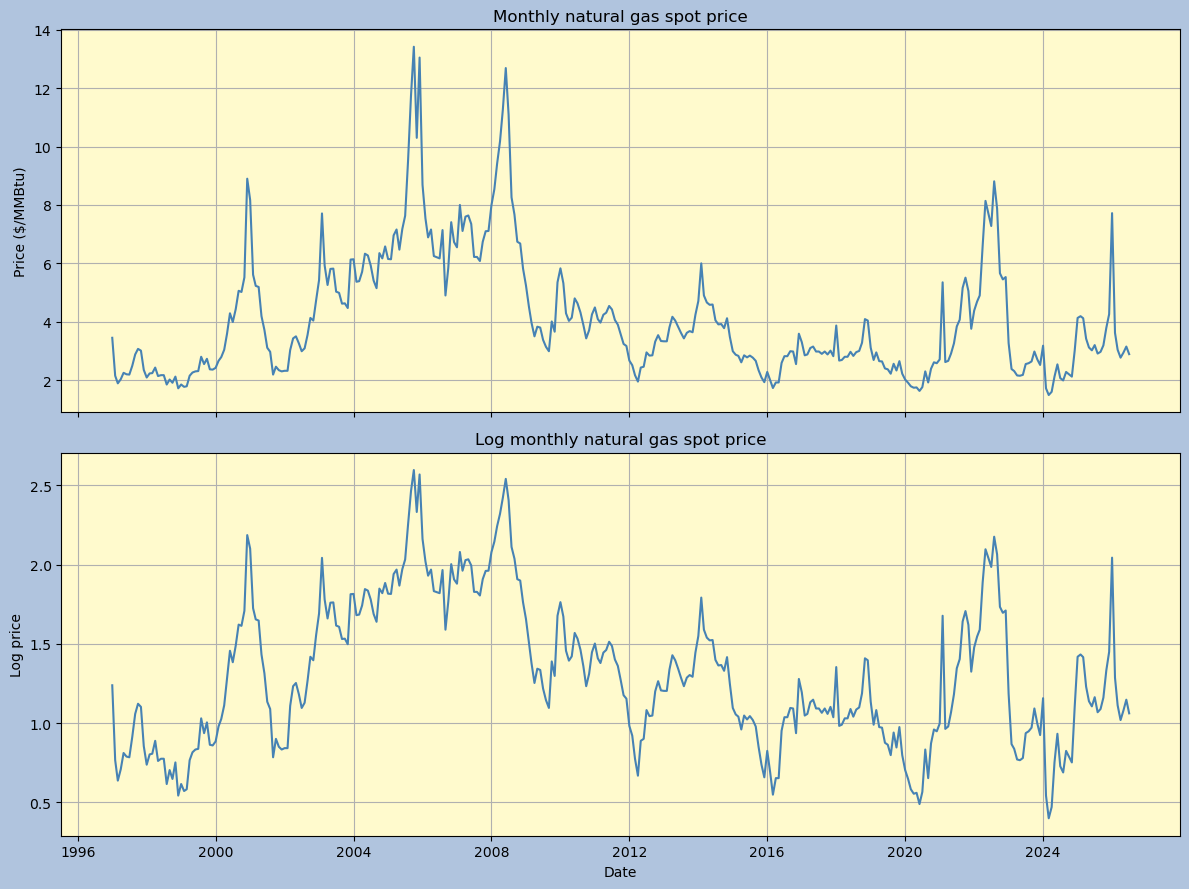

In [48]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 9),
    facecolor=FIGURE_COLOUR,
    sharex=True,
)

for ax in axes:
    ax.set_facecolor(AXIS_COLOUR)

# Plotting actual price data 
axes[0].plot(
    gas_prices.index.to_numpy(),
    gas_prices["Price"].to_numpy(),
    color=HISTORICAL_COLOUR,
)
axes[0].set_title("Monthly natural gas spot price")
axes[0].set_ylabel("Price ($/MMBtu)")

# Plotting log price data
axes[1].plot(
    gas_prices.index.to_numpy(),
    np.log(gas_prices["Price"].to_numpy()),
    color=HISTORICAL_COLOUR,
)
axes[1].set_title("Log monthly natural gas spot price")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log price")

plt.tight_layout()
plt.show()

Gas prices are usually fairly stable but sometimes experience very large spikes. Taking logs makes those spikes less extreme and ensures that converted forecasts stay positive. Prices also show persistence, meaning high prices tend to be followed by high prices, so past prices are useful for prediction. However, past prices alone probably cannot explain sudden movements, so we also consider variables such as storage and weather.

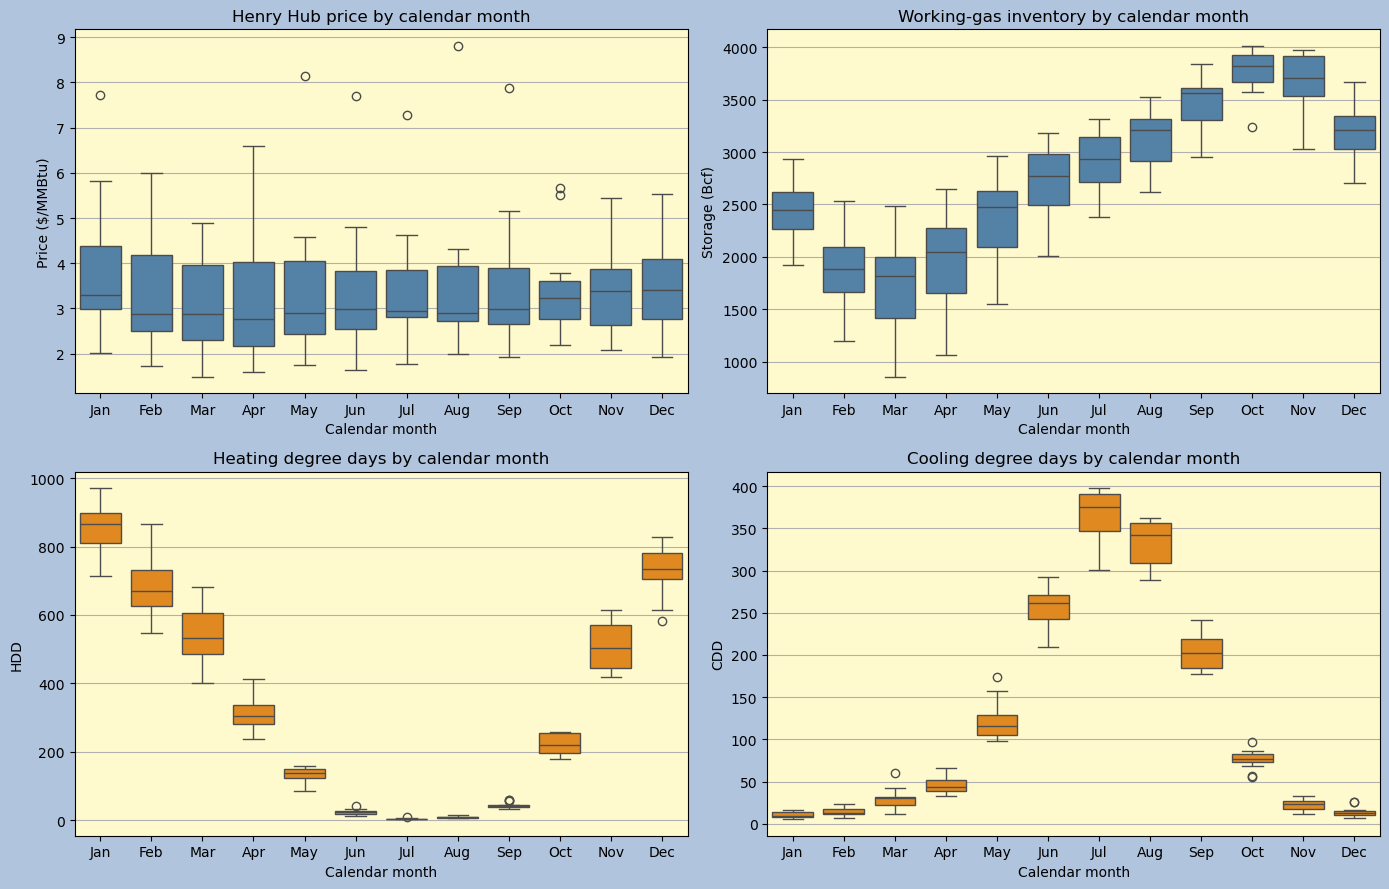

In [49]:
# Builds available EIA data up to forecast_year
def point_in_time_history(forecast_year):
    # use only vintage files that had been released by this forecast year
    available_history = vintage_data[
        (vintage_data["vintage_year"] <= forecast_year)
        & (vintage_data["status"] == "history_or_estimate")
    ].sort_values(["date", "vintage_year"])

    # the latest version available in that forecast year replaces earlier revisions
    return (
        available_history.drop_duplicates("date", keep="last")
        .set_index("date")
        .sort_index()
        .asfreq("MS")
    )


latest_history = point_in_time_history(2026)
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

# Drivers: HDD, CDD, storage 
# Adds month labels to driver data
driver_plot_data = latest_history.assign(
    Month=pd.Categorical(
        latest_history.index.strftime("%b"),
        categories=month_names,
        ordered=True,
    )
)

# Adds month labels to observed prices used for EDA
price_plot_data = gas_prices.loc["2010-01-01":].assign(
    Month=pd.Categorical(
        gas_prices.loc["2010-01-01":].index.strftime("%b"),
        categories=month_names,
        ordered=True,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor=FIGURE_COLOUR)
for ax in axes.flat:
    ax.set_facecolor(AXIS_COLOUR)

# Spot price distribution 
sns.boxplot(data=price_plot_data, x="Month", y="Price", color=HISTORICAL_COLOUR, ax=axes[0, 0])
axes[0, 0].set_title("Henry Hub price by calendar month")
axes[0, 0].set_ylabel("Price ($/MMBtu)")

# Monthly gas storage distribution
sns.boxplot(data=driver_plot_data, x="Month", y="storage", color=HISTORICAL_COLOUR, ax=axes[0, 1])
axes[0, 1].set_title("Working-gas inventory by calendar month")
axes[0, 1].set_ylabel("Storage (Bcf)")

# Monthly HDD distribution
sns.boxplot(data=driver_plot_data, x="Month", y="hdd", color=FORECAST_COLOUR, ax=axes[1, 0])
axes[1, 0].set_title("Heating degree days by calendar month")
axes[1, 0].set_ylabel("HDD")

# Monthly CDD distribution
sns.boxplot(data=driver_plot_data, x="Month", y="cdd", color=FORECAST_COLOUR, ax=axes[1, 1])
axes[1, 1].set_title("Cooling degree days by calendar month")
axes[1, 1].set_ylabel("CDD")

for ax in axes.flat:
    ax.set_xlabel("Calendar month")

plt.tight_layout()
plt.show()

Spot prices do not show a clear monthly pattern because the price distributions overlap heavily across months. This means price seasonality should be tested rather than assumed.

The potential drivers show much stronger seasonal patterns. Storage generally builds through warmer months and falls during winter, HDD is highest in winter, and CDD is highest in summer. These inputs allow a fundamentals model to produce a seasonal forecast path even if an explicit seasonal price error term is not retained.

> Note: The observed Henry Hub series is used for the wider EDA. The stationarity and model checks use the exact point-in-time history available at the first development forecast year, while every rolling fit uses the history available at its own forecast year.

## 5. Stationarity check

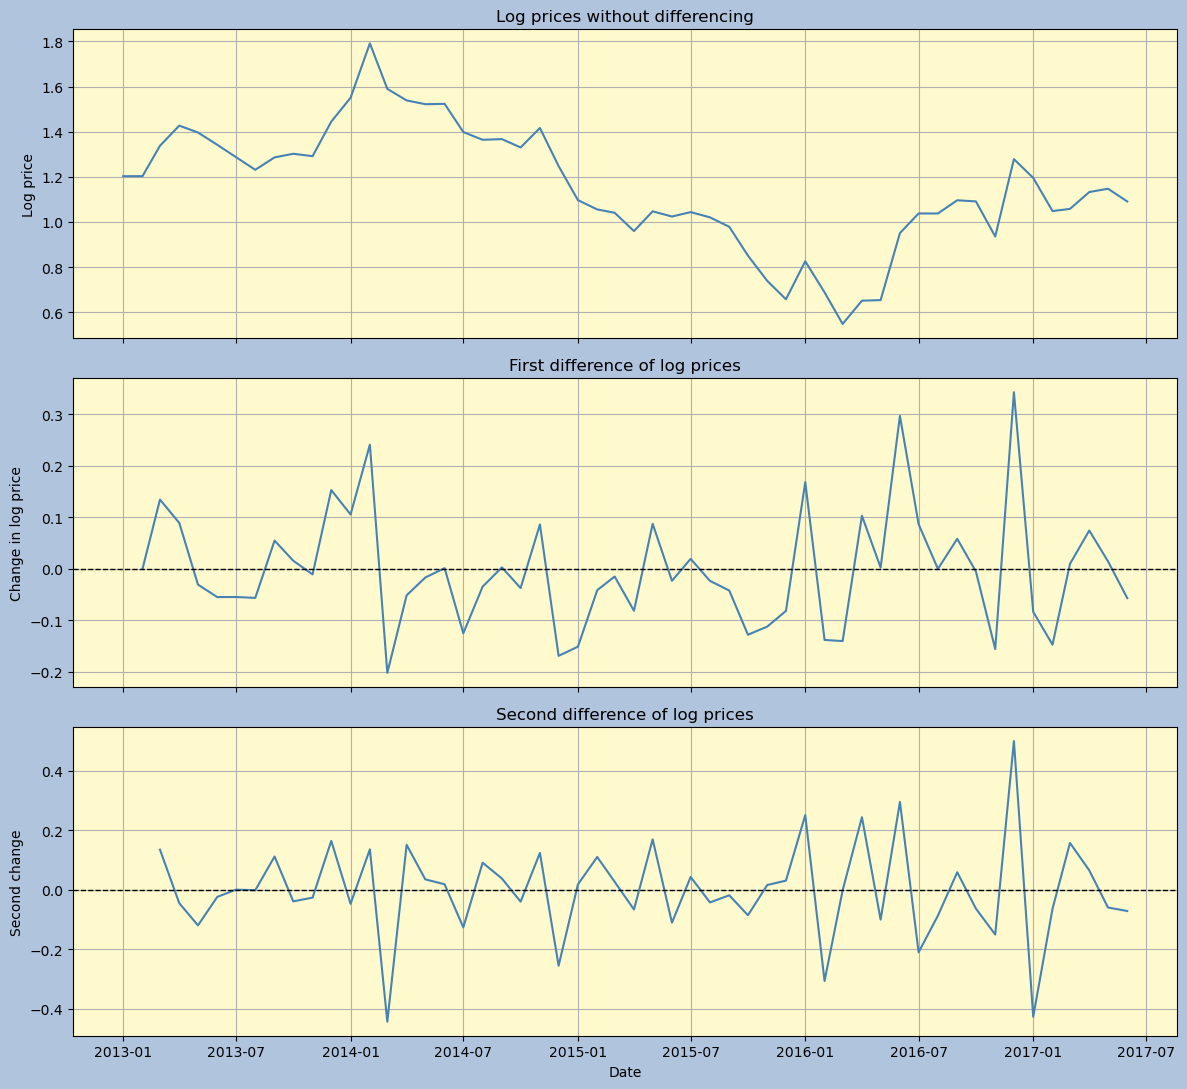

,ADF p-value
Log-price level,5.25e-01
First difference,1.74e-10
Second difference,4.01e-06


First-difference lag-one autocorrelation: -0.028
Second-difference lag-one autocorrelation: -0.482


In [50]:
# Use the same point-in-time price history as the first development forecast
diagnostic_prices = point_in_time_history(2017)["price"]

diagnostic_log_prices = np.log(diagnostic_prices)
first_difference = diagnostic_log_prices.diff().dropna()
second_difference = first_difference.diff().dropna()

# Test the level and the first two differences for a unit root
adf_results = pd.Series({
    "Log-price level": adfuller(diagnostic_log_prices)[1],
    "First difference": adfuller(first_difference)[1],
    "Second difference": adfuller(second_difference)[1],
}, name="ADF p-value")

fig, axes = plt.subplots(3, 1, figsize=(12, 11), facecolor=FIGURE_COLOUR, sharex=True)
for ax in axes:
    ax.set_facecolor(AXIS_COLOUR)

# Plot the log-price level
axes[0].plot(
    diagnostic_log_prices.index.to_numpy(),
    diagnostic_log_prices.to_numpy(),
    color=HISTORICAL_COLOUR,
)
axes[0].set_title("Log prices without differencing")
axes[0].set_ylabel("Log price")

# Plot the first difference
axes[1].plot(
    first_difference.index.to_numpy(),
    first_difference.to_numpy(),
    color=HISTORICAL_COLOUR,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("First difference of log prices")
axes[1].set_ylabel("Change in log price")

# Plot the second difference
axes[2].plot(
    second_difference.index.to_numpy(),
    second_difference.to_numpy(),
    color=HISTORICAL_COLOUR,
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Second difference of log prices")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Second change")

plt.tight_layout()
plt.show()

display(adf_results.to_frame().style.format("{:.2e}"))

print(
    f"First-difference lag-one autocorrelation: "
    f"{first_difference.autocorr(1):.3f}"
)
print(
    f"Second-difference lag-one autocorrelation: "
    f"{second_difference.autocorr(1):.3f}"
)

The level ADF p-value is $0.525$, so we fail to reject a unit root. After one difference it falls to $1.74\times10^{-10}$, giving strong evidence against a unit root in the differenced series. This means that $d=1$ must be included in the model comparison rather than ignored, but it does not mean a differenced model has to be selected regardless of forecast performance.

The first-difference lag-one autocorrelation is $-0.028$, while second differencing changes it to $-0.482$. That strong negative relationship is a warning that $d=2$ removes too much structure. We therefore compare $d=0$ and $d=1$ models using the same point-in-time development backtest.

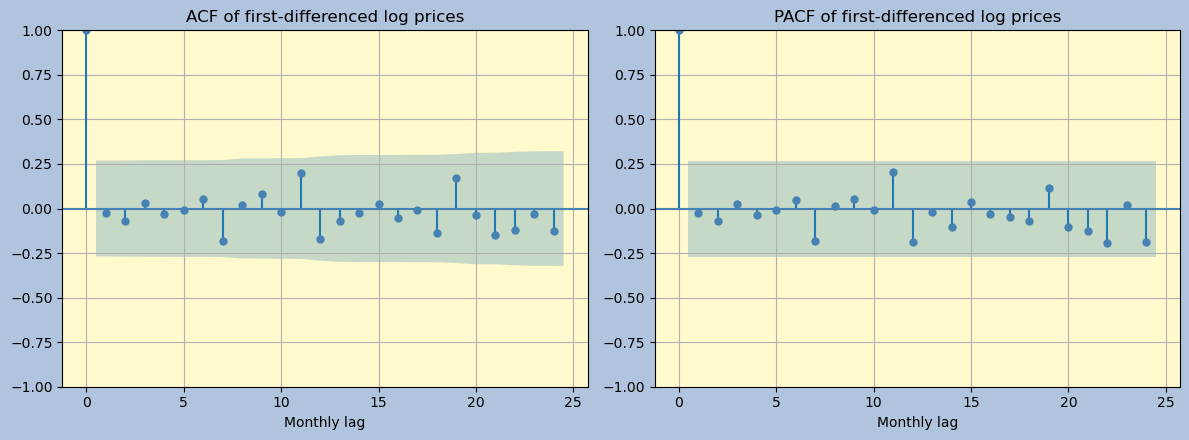

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=FIGURE_COLOUR)
for ax in axes:
    ax.set_facecolor(AXIS_COLOUR)

# ACF plot for first differenced log prices, 24 monthly lags
plot_acf(
    first_difference,
    lags=24,
    ax=axes[0],
    color=HISTORICAL_COLOUR,
)
axes[0].set_title("ACF of first-differenced log prices")
axes[0].set_xlabel("Monthly lag")

# PACF plot for first-differenced log prices, 24 lags, using yule walker method
plot_pacf(
    first_difference,
    lags=24,
    method="ywm",
    ax=axes[1],
    color=HISTORICAL_COLOUR,
)
axes[1].set_title("PACF of first-differenced log prices")
axes[1].set_xlabel("Monthly lag")

plt.tight_layout()
plt.show()

The ACF and PACF of the first-differenced prices show no strong higher-order structure or clear repeating spikes at lags 12 or 24. This suggests that a small set of simple $d=1$ models is enough, rather than carrying out a large parameter search.

The simplest of these, ARIMA(0,1,0), effectively carries the latest price forward, so it gives the same central forecast as the last-price baseline. The remaining models test whether short-term price patterns, storage and weather forecasts, or yearly seasonality improve the forecast.

## 6. Candidate model specifications

The fundamentals models use three forecast-time inputs:

- **storage surplus**: gas inventory compared with the calendar-month average in the training data
- **heating degree days (HDD)**: a measure of heating demand
- **cooling degree days (CDD)**: a measure of cooling demand

For each forecast year, future storage, HDD and CDD come from that July's archived EIA forecast. Only information available at the time is used.

We compare:

- simple last-price and seasonal-naive baselines
- the EIA price forecast as an external benchmark
- ARIMA and SARIMA price-only models
- ARIMAX and SARIMAX models using storage, HDD and CDD
- a weather-deviation version of ARIMAX
- several simple $d=1$ models

All statistical models use log prices. The final model is chosen later using the development backtest.

In [52]:
# Model specifications
MODEL_SPECS = {

    # No differencing models
    "ARIMA(1,0,0)": {
        "order": (1, 0, 0),
        "seasonal_order": (0, 0, 0, 0),
        "features": [],
        "trend": "c",
    },

    "SARIMA(1,0,0)x(1,0,0,12)": {
        "order": (1, 0, 0),
        "seasonal_order": (1, 0, 0, 12),
        "features": [],
        "trend": "c",
    },

    "ARIMAX + fundamentals": {
        "order": (1, 0, 0),
        "seasonal_order": (0, 0, 0, 0),
        "features": ["storage_surplus", "hdd", "cdd"],
        "trend": "c",
    },

    "SARIMAX + fundamentals": {
        "order": (1, 0, 0),
        "seasonal_order": (1, 0, 0, 12),
        "features": ["storage_surplus", "hdd", "cdd"],
        "trend": "c",
    },

    "ARIMAX + weather deviations": {
        "order": (1, 0, 0),
        "seasonal_order": (0, 0, 0, 0),
        "features": ["storage_surplus", "hdd_deviation", "cdd_deviation"],
        "trend": "c",
    },


    # First-differenced price-only models
    "ARIMA(1,1,0)": {
        "order": (1, 1, 0),
        "seasonal_order": (0, 0, 0, 0),
        "features": [],
        "trend": "n",
    },

    "ARIMA(0,1,1)": {
        "order": (0, 1, 1),
        "seasonal_order": (0, 0, 0, 0),
        "features": [],
        "trend": "n",
    },

    "ARIMA(1,1,1)": {
        "order": (1, 1, 1),
        "seasonal_order": (0, 0, 0, 0),
        "features": [],
        "trend": "n",
    },


    # First-differenced models with fundamentals
    "ARIMAX(0,1,0) + fundamentals": {
        "order": (0, 1, 0),
        "seasonal_order": (0, 0, 0, 0),
        "features": ["storage_surplus", "hdd", "cdd"],
        "trend": "n",
    },

    "ARIMAX(1,1,0) + fundamentals": {
        "order": (1, 1, 0),
        "seasonal_order": (0, 0, 0, 0),
        "features": ["storage_surplus", "hdd", "cdd"],
        "trend": "n",
    },

    "ARIMAX(0,1,1) + fundamentals": {
        "order": (0, 1, 1),
        "seasonal_order": (0, 0, 0, 0),
        "features": ["storage_surplus", "hdd", "cdd"],
        "trend": "n",
    },

    "ARIMAX(1,1,1) + fundamentals": {
        "order": (1, 1, 1),
        "seasonal_order": (0, 0, 0, 0),
        "features": ["storage_surplus", "hdd", "cdd"],
        "trend": "n",
    },


    # First-differenced seasonal fundamentals model
    "SARIMAX(0,1,0)x(1,0,0,12) + fundamentals": {
        "order": (0, 1, 0),
        "seasonal_order": (1, 0, 0, 12),
        "features": ["storage_surplus", "hdd", "cdd"],
        "trend": "n",
    },
}


# Function to clean and prepare the raw EIA storage and weather data
def prepare_features(training_data, future_data):
    # Duplicate originals so they are left unchanged
    training = training_data.copy()
    future = future_data.copy()

    # Create storage surplus and HDD/CDD deviations
    monthly_storage_average = training.groupby(training.index.month)["storage"].mean()
    for frame in (training, future):
        expected_storage = frame.index.month.map(monthly_storage_average).to_numpy()
        frame["storage_surplus"] = (frame["storage"] - expected_storage) / expected_storage
        frame["hdd_deviation"] = frame["hdd"] - frame["hdd_normal"]
        frame["cdd_deviation"] = frame["cdd"] - frame["cdd_normal"]

    # Standardise using the training data only
    feature_names = [
        "storage_surplus", "hdd", "cdd", "hdd_deviation", "cdd_deviation"
    ]
    feature_means = training[feature_names].mean()
    feature_scales = training[feature_names].std(ddof=0).replace(0, 1)

    training_features = (training[feature_names] - feature_means) / feature_scales
    future_features = (future[feature_names] - feature_means) / feature_scales
    return training_features, future_features


# Function to fit the price model
def fit_price_model(training_prices, settings, training_features=None):
    model = SARIMAX(
        np.log(training_prices),
        exog=training_features,
        order=settings["order"],
        seasonal_order=settings["seasonal_order"],
        trend=settings["trend"],
        enforce_stationarity=True,
        enforce_invertibility=True,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.filterwarnings(
            "ignore",
            message="Non-stationary starting autoregressive parameters found",
        )
        warnings.filterwarnings(
            "ignore",
            message="Non-invertible starting MA parameters found",
        )
        fitted_model = model.fit(disp=False, maxiter=1_000)

    # Retry the same specification if the first optimiser stops early
    if not fitted_model.mle_retvals.get("converged", False):
        fitted_model = model.fit(method="bfgs", disp=False, maxiter=1_000)
    if not fitted_model.mle_retvals.get("converged", False):
        raise RuntimeError("the price model did not converge")

    return fitted_model

## 7. Vintage backtest

We use July 2017 to July 2023 as seven development forecast years. Each year produces a fixed 12-month August to July forecast, giving 84 monthly forecast errors in total.

Only these development results are used to select the model. The external EIA forecast and two simple baselines stay as useful comparisons, but the selected model must come from `MODEL_SPECS`, converge at every forecast date and have the lowest pooled MAE.

July 2024 and July 2025 are reported later as additional evaluations. The July 2026 vintage is used only after model selection to produce the current forecast.

MAE is the main accuracy measure because it gives the average error in $/MMBtu. RMSE gives more weight to large errors, interval coverage checks how often the realised price falls inside the model interval, and median annual MAE describes a more typical forecast year.

At each forecast date, only information available at that time is used. The first 2017 model therefore trains on data from January 2013 to June 2017.

In [53]:
# Forecast using the price from current month last year
def seasonal_naive_forecast(training_prices, forecast_dates):
    known_or_forecast = training_prices.to_dict()
    predictions = []
    for date in forecast_dates:
        prediction = known_or_forecast[date - pd.DateOffset(years=1)]
        known_or_forecast[date] = prediction
        predictions.append(prediction)
    return pd.Series(predictions, index=forecast_dates)


# Creates all forecasts for one forecast year
def create_forecasts(forecast_year):
    # Select the archived vintage for this year
    forecast_vintage = (
        vintage_data[vintage_data["vintage_year"] == forecast_year]
        .set_index("date")
        .sort_index()
    )
    # Recreate the historical data available at this time
    training_data = point_in_time_history(forecast_year)
    historical_end = training_data.index.max()

    # Create the internal forecast dates
    internal_dates = pd.date_range(
        historical_end + pd.offsets.MonthBegin(1),
        f"{forecast_year + 1}-07-01",
        freq="MS",
    )
    # Create the 12-month period we evaluate
    evaluation_dates = pd.date_range(
        f"{forecast_year}-08-01",
        f"{forecast_year + 1}-07-01",
        freq="MS",
    )
    # Get the future EIA inputs published for this forecast year
    future_data = forecast_vintage.reindex(internal_dates)

    # Sanity checks
    assert historical_end == pd.Timestamp(f"{forecast_year}-06-01")
    assert len(internal_dates) == 13 and len(evaluation_dates) == 12
    assert future_data[required_vintage_columns].notna().all().all()

    # Prepares the features
    training_features, future_features = prepare_features(training_data, future_data)
    training_prices = training_data["price"]
    actual_prices = gas_prices["Price"].reindex(evaluation_dates)

    # Creates the benchmark forecasts
    forecast_frames = []
    baseline_forecasts = {
        "Last price": pd.Series(training_prices.iloc[-1], index=internal_dates),
        "Seasonal naive": seasonal_naive_forecast(training_prices, internal_dates),
        "EIA STEO forecast": forecast_vintage["price"].reindex(internal_dates),
    }
    # Loop through benchmarks and save their results
    for model_name, prediction in baseline_forecasts.items():
        forecast_frames.append(pd.DataFrame({
            "Forecast Year": forecast_year,
            "Date": evaluation_dates,
            "Model": model_name,
            "Actual": actual_prices.to_numpy(),
            "Forecast": prediction.reindex(evaluation_dates).to_numpy(),
            "Lower": np.nan,
            "Upper": np.nan,
        }))

    # Fitting each statistical model
    fit_rows = []
    coefficient_rows = []
    for model_name, settings in MODEL_SPECS.items():
        feature_names = settings["features"]
        training_exog = training_features[feature_names] if feature_names else None
        future_exog = future_features[feature_names] if feature_names else None

        fitted_model = fit_price_model(training_prices, settings, training_exog)
        forecast_result = fitted_model.get_forecast(
            steps=len(internal_dates),
            exog=future_exog,
        )
        forecast = np.exp(forecast_result.predicted_mean)
        interval = np.exp(forecast_result.conf_int())

        # Save statistical forecasts
        forecast_frames.append(pd.DataFrame({
            "Forecast Year": forecast_year,
            "Date": evaluation_dates,
            "Model": model_name,
            "Actual": actual_prices.to_numpy(),
            "Forecast": forecast.reindex(evaluation_dates).to_numpy(),
            "Lower": interval.iloc[:, 0].reindex(evaluation_dates).to_numpy(),
            "Upper": interval.iloc[:, 1].reindex(evaluation_dates).to_numpy(),
        }))
        # Save fitting information
        fit_rows.append({
            "Forecast Year": forecast_year,
            "Model": model_name,
            "Converged": fitted_model.mle_retvals.get("converged", False),
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "Observations": fitted_model.nobs,
        })

        # Store each estimated model coefficient with its forecast year and model name
        for parameter, value in fitted_model.params.items():
            coefficient_rows.append({
                "Forecast Year": forecast_year,
                "Model": model_name,
                "Parameter": parameter,
                "Estimate": value,
            })

    return (
        pd.concat(forecast_frames, ignore_index=True),
        pd.DataFrame(fit_rows),
        pd.DataFrame(coefficient_rows),
    )

# Run the forecasting process for each year and combine the results
def run_forecast_years(forecast_years):
    forecast_frames = []
    fit_frames = []
    coefficient_frames = []

    # Combining the requested forecast years
    for forecast_year in forecast_years:
        year_forecasts, year_fits, year_coefficients = create_forecasts(forecast_year)
        forecast_frames.append(year_forecasts)
        fit_frames.append(year_fits)
        coefficient_frames.append(year_coefficients)

    forecast_results = pd.concat(forecast_frames, ignore_index=True)
    fit_results = pd.concat(fit_frames, ignore_index=True)
    coefficient_results = pd.concat(coefficient_frames, ignore_index=True)

    # Calculating forecast errors
    forecast_results["Error"] = forecast_results["Forecast"] - forecast_results["Actual"]
    forecast_results["Absolute_error"] = forecast_results["Error"].abs()
    forecast_results["Squared_error"] = forecast_results["Error"] ** 2
    has_interval = forecast_results["Lower"].notna() & forecast_results["Actual"].notna()
    forecast_results["Covered"] = np.where(
        has_interval,
        (forecast_results["Actual"] >= forecast_results["Lower"])
        & (forecast_results["Actual"] <= forecast_results["Upper"]),
        np.nan,
    )

    return forecast_results, fit_results, coefficient_results


# Running the development backtest
development_results, development_fit_results, development_coefficient_results = (
    run_forecast_years(range(2017, 2024))
)

print(f"All development models converged: {development_fit_results['Converged'].all()}")
print(f"Development forecast years recreated: {development_results['Forecast Year'].nunique()}")

All development models converged: True
Development forecast years recreated: 7


> Note: The full results from the calculations above are saved to an Excel file. Not every statistic calculated here is used directly later in the project, but I have kept them because they provide useful additional diagnostic information.

In [54]:
# Sort the complete development backtest results
full_forecast_results = development_results.sort_values(
    ["Forecast Year", "Model", "Date"]
)

full_fit_results = development_fit_results.sort_values(
    ["Forecast Year", "Model"]
)

full_coefficient_results = development_coefficient_results.sort_values(
    ["Forecast Year", "Model", "Parameter"]
)

# Create an output folder if it does not already exist
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Save the complete development backtest results to an Excel workbook
output_file = output_dir / "development_backtest_results.xlsx"

with pd.ExcelWriter(output_file) as writer:
    full_forecast_results.to_excel(
        writer,
        sheet_name="Forecast Results",
        index=False,
    )

    full_fit_results.to_excel(
        writer,
        sheet_name="Model Fits",
        index=False,
    )

    full_coefficient_results.to_excel(
        writer,
        sheet_name="Model Coefficients",
        index=False,
    )

print(f"Full development results saved to {output_file}")

Full development results saved to outputs/development_backtest_results.xlsx


In [55]:
# Calculate the model metrics
def metric_summary(results):
    rows = []
    for model_name, model_results in results.groupby("Model", sort=False):
        interval_results = model_results["Covered"].dropna()
        rows.append({
            "Model": model_name,
            "MAE": model_results["Absolute_error"].mean(),
            "RMSE": np.sqrt(model_results["Squared_error"].mean()),
            "Bias": model_results["Error"].mean(),
            "95% interval coverage": (
                interval_results.mean() if len(interval_results) else np.nan
            ),
        })
    return pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)


# Compare development results
development_summary = metric_summary(development_results)
annual_mae = (
    development_results.groupby(["Forecast Year", "Model"])["Absolute_error"]
    .mean()
    .reset_index(name="MAE")
)
median_annual_mae = (
    annual_mae.groupby("Model")["MAE"]
    .median()
    .rename("Median annual MAE")
)
development_summary = development_summary.merge(
    median_annual_mae,
    on="Model",
)

# Select the converged statistical model with the lowest pooled MAE
candidate_convergence = development_fit_results.groupby("Model")["Converged"].all()
eligible_model_names = candidate_convergence[candidate_convergence].index
eligible_results = (
    development_summary[development_summary["Model"].isin(eligible_model_names)]
    .sort_values("MAE")
    .reset_index(drop=True)
)
if eligible_results.empty:
    raise RuntimeError("no statistical model converged at every development forecast year")

selected_model = eligible_results.iloc[0]["Model"]
selected_settings = MODEL_SPECS[selected_model]

# Identify the strongest first-differenced candidate for a direct comparison
differenced_model_names = [
    name for name, settings in MODEL_SPECS.items()
    if settings["order"][1] == 1
]
best_differenced_result = (
    development_summary[development_summary["Model"].isin(differenced_model_names)]
    .sort_values("MAE")
    .iloc[0]
)
best_differenced_model = best_differenced_result["Model"]
differencing_comparison = development_summary[
    development_summary["Model"].isin([selected_model, best_differenced_model])
]

display(development_summary)
print("Selected model:", selected_model)
print("Best first-differenced candidate:", best_differenced_model)
display(differencing_comparison)


,Model,MAE,RMSE,Bias,95% interval coverage,Median annual MAE
0,ARIMAX + fundamentals,0.890369,1.321685,-0.123995,0.773810,0.656407
1,SARIMAX + fundamentals,0.912753,1.335148,-0.135228,0.761905,0.646385
2,ARIMAX + weather deviations,0.925999,1.362791,-0.147402,0.738095,0.721494
3,"ARIMA(1,0,0)",1.004893,1.462452,-0.186569,0.785714,0.729107
4,"SARIMA(1,0,0)x(1,0,0,12)",1.012612,1.469122,-0.190791,0.785714,0.730429
5,EIA STEO forecast,1.033148,1.531545,0.018191,NaN,0.647734
6,"ARIMAX(1,1,1) + fundamentals",1.086361,1.640854,-0.005234,0.750000,0.548255
7,"SARIMAX(0,1,0)x(1,0,0,12) + fundamentals",1.116407,1.749032,-0.015546,0.869048,0.441668
8,"ARIMAX(0,1,0) + fundamentals",1.120952,1.812056,0.053244,0.869048,0.405147
9,"ARIMAX(1,1,0) + fundamentals",1.149721,1.846142,0.046954,0.821429,0.410707


Selected model: ARIMAX + fundamentals
Best first-differenced candidate: ARIMAX(1,1,1) + fundamentals


,Model,MAE,RMSE,Bias,95% interval coverage,Median annual MAE
0,ARIMAX + fundamentals,0.890369,1.321685,-0.123995,0.77381,0.656407
6,"ARIMAX(1,1,1) + fundamentals",1.086361,1.640854,-0.005234,0.75000,0.548255


The $d=1$ candidates provide a useful sensitivity check alongside the level models. The best pooled $d=1$ model is ARIMAX (1,1,1) with fundamentals, with an MAE of $1.086$ $/MMBtu, compared with $0.890$ for the selected level ARIMAX. Its lower median annual MAE, 0.548 versus 0.656, shows that performance varies across forecast years.

The ARIMAX + Fudamentals is selected because the model-selection rule was defined in advance as the lowest pooled MAE across the development years. This choice is based on forecasting performance and does not imply that the log-price level is strictly stationary.

In [56]:
# Checking whether one year determines model selection
leave_one_out_rows = []
for excluded_year in range(2017, 2024):
    remaining = development_results[
        (development_results["Forecast Year"] != excluded_year)
        & development_results["Model"].isin(eligible_model_names)
    ]
    leave_one_out = (
        remaining.groupby("Model")["Absolute_error"]
        .mean()
        .sort_values()
    )
    leave_one_out_rows.append({
        "Excluded year": excluded_year,
        "Lowest-MAE model": leave_one_out.index[0],
        "Lowest MAE": leave_one_out.iloc[0],
    })

leave_one_out_check = pd.DataFrame(leave_one_out_rows)
selected_remains_best = (
    leave_one_out_check["Lowest-MAE model"] == selected_model
).sum()
# Checking how often the selected model beats the last price baseline
selected_annual = annual_mae[annual_mae["Model"] == selected_model]
last_price_annual = annual_mae[annual_mae["Model"] == "Last price"]
selected_beats_last = (
    selected_annual.set_index("Forecast Year")["MAE"]
    < last_price_annual.set_index("Forecast Year")["MAE"]
).sum()

display(leave_one_out_check)
print(f"Selected model remains best in {selected_remains_best} of 7 leave-one-year-out checks.")
print(f"Selected model beats the last-price baseline in {selected_beats_last} of 7 periods.")

,Excluded year,Lowest-MAE model,Lowest MAE
0,2017,ARIMAX + fundamentals,0.988675
1,2018,ARIMAX + fundamentals,0.961162
2,2019,ARIMAX + fundamentals,0.912636
3,2020,ARIMAX + fundamentals,0.929363
4,2021,ARIMAX + fundamentals,0.673756
5,2022,"ARIMAX(0,1,0) + fundamentals",0.738531
6,2023,ARIMAX + fundamentals,0.971479


Selected model remains best in 6 of 7 leave-one-year-out checks.
Selected model beats the last-price baseline in 4 of 7 periods.


### Backtest comparison

ARIMAX + fundamentals has the lowest pooled development MAE at $0.890$ $/MMBtu and the lowest RMSE at $1.322$. SARIMAX with the same fundamentals has an MAE of $0.913$, so adding an annual seasonal term does not improve pooled forecast performance. The seasonal price-only model is also slightly worse than its non-seasonal version.

Among the $d=1$ models, ARIMAX(1,1,1) with fundamentals has the lowest pooled MAE at $1.086$. However, the ARIMAX + fundamentals level model still performs best overall under the pooled-MAE rule.

The selected model remains best in six of the seven leave one year out checks. When the 2022 forecast year is removed, ARIMAX(0,1,0) with fundamentals becomes best, with an MAE of $0.739$ compared with $0.796$ for the selected model. The selected model also beats the last-price baseline in only four of the seven individual forecast years.

We therefore select ARIMAX + fundamentals using the pre specified pooled MAE rule, while treating the $d=1$ and seasonal models as robustness checks. Its advantage is not consistent across every forecast year. SARIMAX + fundamentals is retained as a secondary seasonal comparison to check whether the annual seasonal term changes the results.

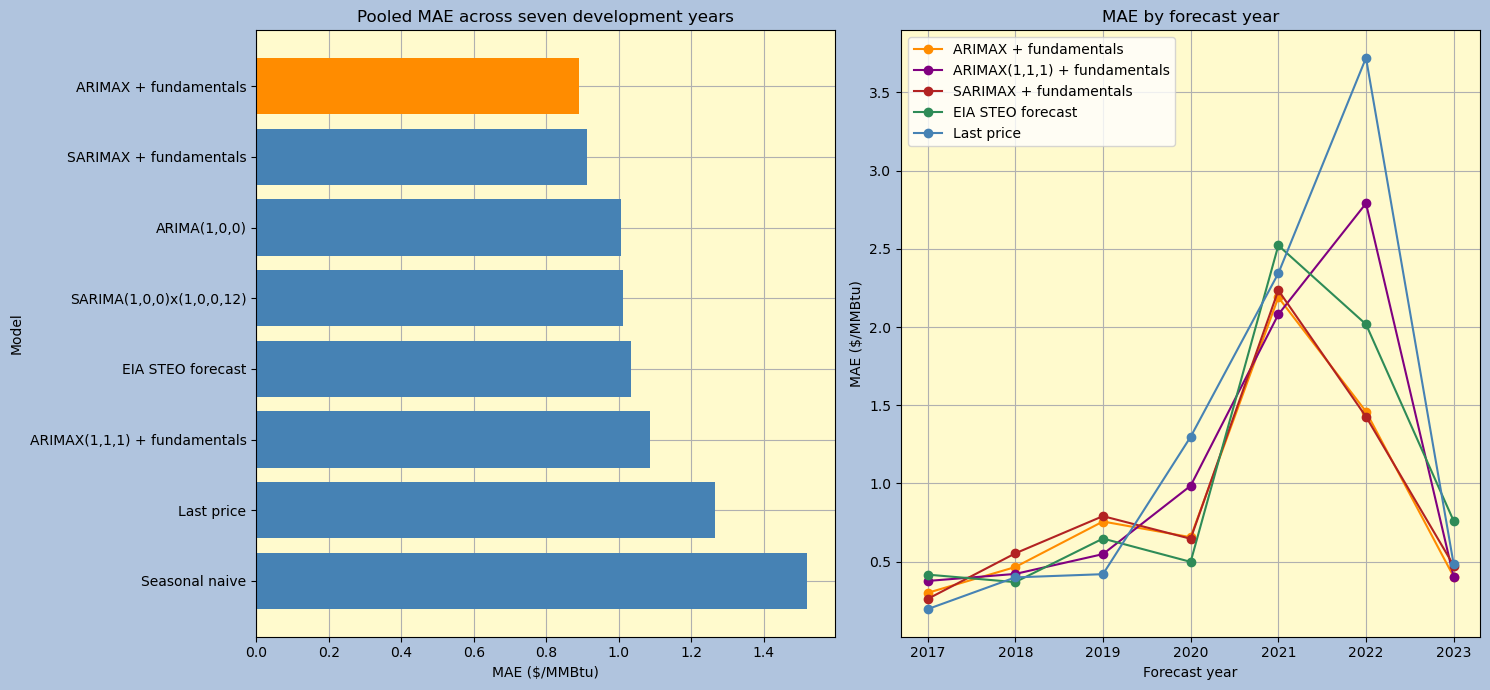

In [57]:
# Plot the main development comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 7), facecolor=FIGURE_COLOUR)
for ax in axes:
    ax.set_facecolor(AXIS_COLOUR)
    ax.set_axisbelow(True)

# Keep the bar chart readable by showing the main models and best d=1 challenger
plotted_model_names = [
    selected_model,
    "SARIMAX + fundamentals",
    best_differenced_model,
    "ARIMA(1,0,0)",
    "SARIMA(1,0,0)x(1,0,0,12)",
    "EIA STEO forecast",
    "Last price",
    "Seasonal naive",
]
plot_summary = development_summary[
    development_summary["Model"].isin(plotted_model_names)
].copy()
bar_colours = [
    FORECAST_COLOUR if model == selected_model else HISTORICAL_COLOUR
    for model in plot_summary["Model"]
]
axes[0].barh(
    plot_summary["Model"].to_numpy(),
    plot_summary["MAE"].to_numpy(),
    color=bar_colours,
)
axes[0].invert_yaxis()
axes[0].set_title("Pooled MAE across seven development years")
axes[0].set_xlabel("MAE ($/MMBtu)")
axes[0].set_ylabel("Model")

# Compare the most informative models year by year
comparison_colours = {
    selected_model: FORECAST_COLOUR,
    best_differenced_model: "purple",
    "SARIMAX + fundamentals": "firebrick",
    "EIA STEO forecast": "seagreen",
    "Last price": HISTORICAL_COLOUR,
}
for model_name, colour in comparison_colours.items():
    model_periods = annual_mae[annual_mae["Model"] == model_name]
    axes[1].plot(
        model_periods["Forecast Year"].to_numpy(),
        model_periods["MAE"].to_numpy(),
        marker="o",
        color=colour,
        label=model_name,
    )

axes[1].set_title("MAE by forecast year")
axes[1].set_xlabel("Forecast year")
axes[1].set_ylabel("MAE ($/MMBtu)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [58]:
# Compare coefficients for the selected model and seasonal sensitivity
coefficient_models = [selected_model, "SARIMAX + fundamentals"]
main_coefficients = development_coefficient_results[
    development_coefficient_results["Model"].isin(coefficient_models)
].copy()

# Remove the intercept and error variance from the comparison
main_coefficients = main_coefficients[
    ~main_coefficients["Parameter"].isin({"intercept", "sigma2"})
]

coefficient_summary = (
    main_coefficients.groupby(["Model", "Parameter"])["Estimate"]
    .agg(["min", "median", "max"])
    .rename(columns={"min": "Minimum", "median": "Median", "max": "Maximum"})
)
coefficient_summary["Same sign every year"] = (
    main_coefficients.groupby(["Model", "Parameter"])["Estimate"]
    .apply(lambda values: values.gt(0).all() or values.lt(0).all())
)

coefficient_summary

Minimum    Median   Maximum  \
Model                  Parameter                                       
ARIMAX + fundamentals  ar.L1            0.791646  0.843815  0.893173   
                       cdd              0.014876  0.027048  0.037483   
                       hdd              0.027293  0.039762  0.055893   
                       storage_surplus -0.197206 -0.165412 -0.128709   
SARIMAX + fundamentals ar.L1            0.808441  0.867125  0.906214   
                       ar.S.L12        -0.265554 -0.140565 -0.126430   
                       cdd              0.011785  0.023399  0.037566   
                       hdd              0.024004  0.032309  0.050284   
                       storage_surplus -0.198675 -0.157136 -0.130492   

                                        Same sign every year  
Model                  Parameter                              
ARIMAX + fundamentals  ar.L1                            True  
                       cdd                              True  
                       hdd                              True  
                       storage_surplus                  True  
SARIMAX + fundamentals ar.L1                            True  
                       ar.S.L12                         True  
                       cdd                              True  
                       hdd                              True  
                       storage_surplus                  True

### Coefficient check

The external features are standardised within each forecast year, making their coefficients more comparable across fits. Both ARIMAX and SARIMAX show similar and stable relationships. Storage surplus is negative every year, while HDD and CDD are positive every year. This is consistent with higher gas inventories being associated with lower prices, and stronger heating or cooling demand being associated with higher prices.

The AR(1) coefficient is also positive and stable in both models, indicating positive persistence from the previous month. In SARIMAX, the seasonal AR(12) coefficient is negative every year, so its sign is also consistent across the development period.

Overall, adding the seasonal term does not substantially change the signs or sizes of the fundamental relationships. These coefficients describe predictive relationships in this dataset and should not be interpreted as causal effects.

### Residual diagnostics

Forecast performance is the main basis for comparing the models, but the residuals of both ARIMAX + fundamentals and SARIMAX + fundamentals should also be checked. Ideally, the residuals should show little remaining autocorrelation. Strong autocorrelation would suggest that the model has left a repeatable time-series pattern unexplained.

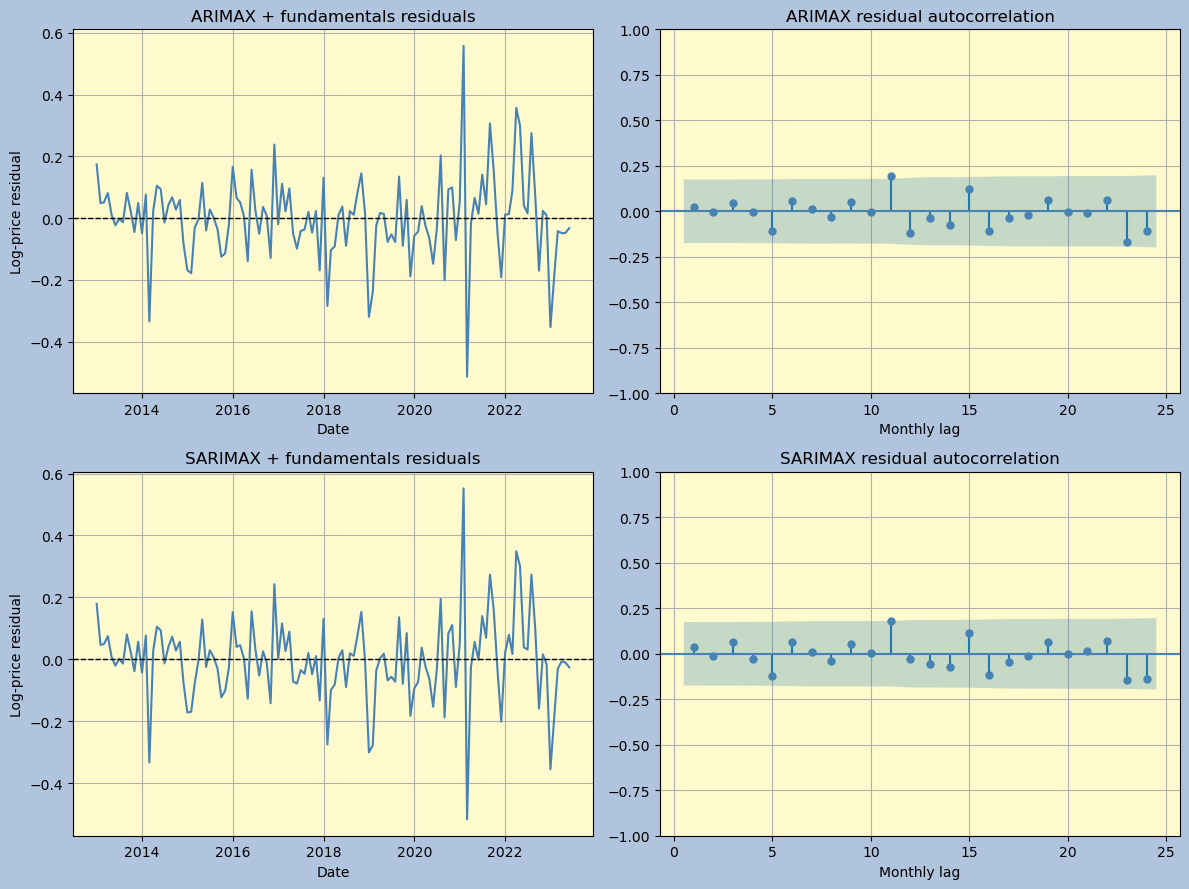

ARIMAX + fundamentals


,Ljung-Box statistic,p-value
12,10.274414,0.505886
24,22.848203,0.469664


SARIMAX + fundamentals


,Ljung-Box statistic,p-value
12,8.735656,0.557361
24,22.034477,0.457832


In [59]:
# Rebuild the July 2023 training data for residual diagnostics
diagnostic_year = 2023

diagnostic_training = point_in_time_history(diagnostic_year)

diagnostic_vintage = (
    vintage_data[vintage_data["vintage_year"] == diagnostic_year]
    .set_index("date")
    .sort_index()
)

# Create the future dates needed to prepare the EIA features
diagnostic_future_dates = pd.date_range(
    f"{diagnostic_year}-07-01",
    f"{diagnostic_year + 1}-07-01",
    freq="MS",
)

# Prepare the historical features using only information available in July 2023
diagnostic_training_features, _ = prepare_features(
    diagnostic_training,
    diagnostic_vintage.reindex(diagnostic_future_dates),
)


# Fit the selected ARIMAX + fundamentals model
arimax_feature_names = selected_settings["features"]

arimax_exog = (
    diagnostic_training_features[arimax_feature_names]
    if arimax_feature_names
    else None
)

arimax_fit = fit_price_model(
    diagnostic_training["price"],
    selected_settings,
    arimax_exog,
)

# Remove the initial observations used to initialise the fitted model
arimax_residuals = arimax_fit.resid.iloc[
    arimax_fit.loglikelihood_burn:
].dropna()


# Fit the secondary SARIMAX + fundamentals model
sarimax_model = "SARIMAX + fundamentals"
sarimax_settings = MODEL_SPECS[sarimax_model]
sarimax_feature_names = sarimax_settings["features"]

sarimax_exog = (
    diagnostic_training_features[sarimax_feature_names]
    if sarimax_feature_names
    else None
)

sarimax_fit = fit_price_model(
    diagnostic_training["price"],
    sarimax_settings,
    sarimax_exog,
)

# Remove the initial observations used to initialise the fitted model
sarimax_residuals = sarimax_fit.resid.iloc[
    sarimax_fit.loglikelihood_burn:
].dropna()


# Plot ARIMAX residual diagnostics on the top row
# and SARIMAX residual diagnostics on the bottom row
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    facecolor=FIGURE_COLOUR,
)

for ax in axes.flat:
    ax.set_facecolor(AXIS_COLOUR)
    ax.set_axisbelow(True)

# ARIMAX residuals over time
axes[0, 0].plot(
    arimax_residuals.index.to_numpy(),
    arimax_residuals.to_numpy(),
    color=HISTORICAL_COLOUR,
)

axes[0, 0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[0, 0].set_title("ARIMAX + fundamentals residuals")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Log-price residual")

# ARIMAX residual autocorrelation
plot_acf(
    arimax_residuals,
    lags=24,
    zero=False,
    ax=axes[0, 1],
    color=HISTORICAL_COLOUR,
)

axes[0, 1].set_title("ARIMAX residual autocorrelation")
axes[0, 1].set_xlabel("Monthly lag")


# SARIMAX residuals over time
axes[1, 0].plot(
    sarimax_residuals.index.to_numpy(),
    sarimax_residuals.to_numpy(),
    color=HISTORICAL_COLOUR,
)

axes[1, 0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1, 0].set_title("SARIMAX + fundamentals residuals")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Log-price residual")

# SARIMAX residual autocorrelation
plot_acf(
    sarimax_residuals,
    lags=24,
    zero=False,
    ax=axes[1, 1],
    color=HISTORICAL_COLOUR,
)

axes[1, 1].set_title("SARIMAX residual autocorrelation")
axes[1, 1].set_xlabel("Monthly lag")

plt.tight_layout()
plt.show()


# Test ARIMAX residuals for remaining autocorrelation
arimax_df = (
    selected_settings["order"][0]
    + selected_settings["order"][2]
    + selected_settings["seasonal_order"][0]
    + selected_settings["seasonal_order"][2]
)

arimax_residual_test = acorr_ljungbox(
    arimax_residuals,
    lags=[12, 24],
    model_df=arimax_df,
    return_df=True,
).rename(columns={
    "lb_stat": "Ljung-Box statistic",
    "lb_pvalue": "p-value",
})


# Test SARIMAX residuals for remaining autocorrelation
sarimax_df = (
    sarimax_settings["order"][0]
    + sarimax_settings["order"][2]
    + sarimax_settings["seasonal_order"][0]
    + sarimax_settings["seasonal_order"][2]
)

sarimax_residual_test = acorr_ljungbox(
    sarimax_residuals,
    lags=[12, 24],
    model_df=sarimax_df,
    return_df=True,
).rename(columns={
    "lb_stat": "Ljung-Box statistic",
    "lb_pvalue": "p-value",
})

print("ARIMAX + fundamentals")
display(arimax_residual_test)

print("SARIMAX + fundamentals")
display(sarimax_residual_test)

The residual ACF shows no strong remaining autocorrelation, and the Ljung–Box tests at lags 12 and 24 are not significant for either model. This suggests that both models capture most of the serial dependence in the price series. The similar diagnostics also show that adding the seasonal AR term does not materially improve the residual structure.

## 8. Out of sample forecast evaluation

In [60]:
# Creating out of sample forecasts
later_results, later_fit_results, later_coefficient_results = run_forecast_years(
    [2024, 2025]
)
if not later_fit_results["Converged"].all():
    raise RuntimeError("an out of sample model did not converge")

backtest_results = pd.concat(
    [development_results, later_results],
    ignore_index=True,
)

# Calculate model performance for the 2024 forecast year
evaluation_2024 = metric_summary(later_results[later_results["Forecast Year"] == 2024])
# Calculate model performance for the 2025 forecast year
evaluation_2025 = metric_summary(later_results[later_results["Forecast Year"] == 2025])

print("July 2024 Forecast: August 2024 to July 2025")
display(evaluation_2024)
print("July 2025 Forecast: August 2025 to July 2026")
display(evaluation_2025)

July 2024 Forecast: August 2024 to July 2025


,Model,MAE,RMSE,Bias,95% interval coverage
0,EIA STEO forecast,0.568331,0.635702,0.015945,NaN
1,"SARIMA(1,0,0)x(1,0,0,12)",0.582975,0.718270,-0.222251,1.000000
2,"ARIMA(1,0,0)",0.616263,0.749759,-0.242425,1.000000
3,"ARIMAX(0,1,0) + fundamentals",0.718999,0.829867,-0.183623,1.000000
4,"ARIMAX(1,1,0) + fundamentals",0.719944,0.832286,-0.195341,1.000000
5,"ARIMAX(0,1,1) + fundamentals",0.720191,0.832878,-0.198091,1.000000
6,"SARIMAX(0,1,0)x(1,0,0,12) + fundamentals",0.733855,0.840291,-0.235477,1.000000
7,ARIMAX + weather deviations,0.739171,0.869784,-0.297992,1.000000
8,"ARIMAX(1,1,1) + fundamentals",0.755526,0.871308,-0.276433,1.000000
9,SARIMAX + fundamentals,0.756944,0.868235,-0.291274,1.000000


July 2025 Forecast: August 2025 to July 2026


,Model,MAE,RMSE,Bias,95% interval coverage
0,"ARIMAX(1,1,1) + fundamentals",0.656050,1.347361,-0.532293,0.916667
1,"ARIMAX(0,1,0) + fundamentals",0.659220,1.259568,-0.266463,0.916667
2,"ARIMAX(1,1,0) + fundamentals",0.660444,1.261175,-0.267540,0.916667
3,"ARIMAX(0,1,1) + fundamentals",0.660798,1.261527,-0.267632,0.916667
4,ARIMAX + fundamentals,0.663216,1.355439,-0.548928,0.916667
5,"SARIMAX(0,1,0)x(1,0,0,12) + fundamentals",0.665090,1.280231,-0.270002,0.916667
6,SARIMAX + fundamentals,0.681187,1.372810,-0.550778,0.916667
7,"ARIMA(1,0,0)",0.684579,1.423656,-0.553851,0.916667
8,"ARIMA(1,1,1)",0.684686,1.424243,-0.555128,0.916667
9,"ARIMA(0,1,1)",0.685993,1.431820,-0.575124,0.916667


The two later periods are not used to change the selected model. Instead, they show how the selected model performs in different market conditions and compare it with the strongest $d=1$ model, the seasonal SARIMAX model and the EIA benchmark.

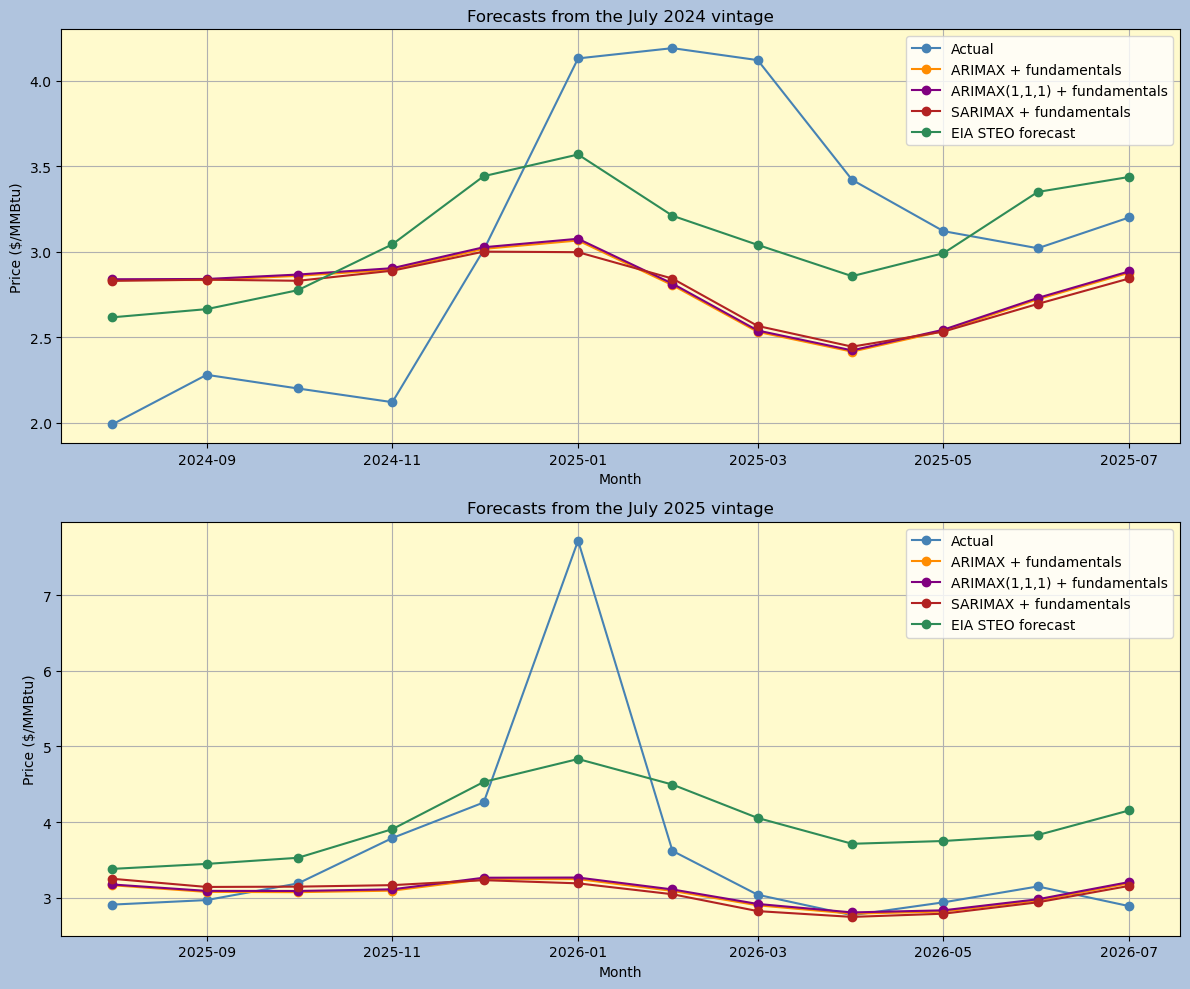

In [61]:
# Choose the main models for the out of sample forecast comparison
comparison_models = [
    selected_model,
    best_differenced_model,
    "SARIMAX + fundamentals",
    "EIA STEO forecast",
]

plot_colours = {
    selected_model: FORECAST_COLOUR,
    best_differenced_model: "purple",
    "SARIMAX + fundamentals": "firebrick",
    "EIA STEO forecast": "seagreen",
}

# Create stacked plots for the 2024 and 2025 forecast years
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 10),
    facecolor=FIGURE_COLOUR,
)

for ax in axes:
    ax.set_facecolor(AXIS_COLOUR)
    ax.set_axisbelow(True)

# Plot each later forecast year
for ax, forecast_year in zip(axes, [2024, 2025]):

    # Get forecasts for the chosen year and models
    plot_data = later_results[
        (later_results["Forecast Year"] == forecast_year)
        & later_results["Model"].isin(comparison_models)
    ]

    # Get the realised prices for the forecast period
    actual_prices = (
        plot_data
        .drop_duplicates("Date")
        .set_index("Date")["Actual"]
    )

    ax.plot(
        actual_prices.index.to_numpy(),
        actual_prices.to_numpy(),
        marker="o",
        color=HISTORICAL_COLOUR,
        label="Actual",
    )

    # Plot each model forecast
    for model_name, colour in plot_colours.items():

        model_curve = (
            plot_data[plot_data["Model"] == model_name]
            .set_index("Date")
        )

        ax.plot(
            model_curve.index.to_numpy(),
            model_curve["Forecast"].to_numpy(),
            marker="o",
            color=colour,
            label=model_name,
        )

    # Format each plot
    ax.set_title(f"Forecasts from the July {forecast_year} vintage")
    ax.set_xlabel("Month")
    ax.set_ylabel("Price ($/MMBtu)")
    ax.legend()

plt.tight_layout()
plt.show()

### Out of sample results

The later results are mixed. In the 2024 period, EIA has the lowest MAE at $0.568$ $/MMBtu. The best $d=1$ fundamentals model for that year records $0.719$, while ARIMAX + fundamentals records $0.757$.

In 2025, ARIMAX(1,1,1) with fundamentals has the lowest MAE at $0.656$, only slightly ahead of ARIMAX + fundamentals at $0.663$. EIA has a higher MAE of $0.846$ but the lowest RMSE because it is closer to the large January 2026 price spike.

These later results show that model performance changes across market conditions, but they are not used to change the model selected from the development backtest. The model’s 95% prediction intervals contain only $77.4%$ of the development observations, suggesting that the model underestimates forecast uncertainty.

## 9. July 2026 Forecast

In [62]:
# Create forecasts for the current 2026 forecast year
current_results, current_fit_results, current_coefficient_results = (
    run_forecast_years([2026])
)

if not current_fit_results["Converged"].all():
    raise RuntimeError("a current-period model did not converge")

# Get the selected ARIMAX forecast
selected_current = (
    current_results[current_results["Model"] == selected_model]
    .set_index("Date")
)

# Get the strongest d=1 model
d1_current = (
    current_results[
        current_results["Model"] == "ARIMAX(1,1,1) + fundamentals"
    ]
    .set_index("Date")
)

# Get the seasonal SARIMAX comparison
sarimax_current = (
    current_results[
        current_results["Model"] == "SARIMAX + fundamentals"
    ]
    .set_index("Date")
)

# Get the published EIA forecast
eia_current = (
    current_results[current_results["Model"] == "EIA STEO forecast"]
    .set_index("Date")["Forecast"]
)

# Get the last-price path
last_price_current = (
    current_results[current_results["Model"] == "Last price"]
    .set_index("Date")["Forecast"]
)

# Create fixed 50/50 model-risk scenarios
selected_blend = 0.5 * selected_current["Forecast"] + 0.5 * eia_current
d1_blend = 0.5 * d1_current["Forecast"] + 0.5 * eia_current
sarimax_blend = 0.5 * sarimax_current["Forecast"] + 0.5 * eia_current

# Selected ARIMAX comparison
selected_forecast_table = pd.DataFrame({
    selected_model: selected_current["Forecast"],
    "Lower 95%": selected_current["Lower"],
    "Upper 95%": selected_current["Upper"],
    "EIA STEO forecast": eia_current,
    "Fixed 50/50 scenario": selected_blend,
})

# Differenced ARIMAX comparison
d1_forecast_table = pd.DataFrame({
    "ARIMAX(1,1,1) + fundamentals": d1_current["Forecast"],
    "Lower 95%": d1_current["Lower"],
    "Upper 95%": d1_current["Upper"],
    "EIA STEO forecast": eia_current,
    "Fixed 50/50 scenario": d1_blend,
})

# Seasonal SARIMAX comparison
sarimax_forecast_table = pd.DataFrame({
    "SARIMAX + fundamentals": sarimax_current["Forecast"],
    "Lower 95%": sarimax_current["Lower"],
    "Upper 95%": sarimax_current["Upper"],
    "EIA STEO forecast": eia_current,
    "Fixed 50/50 scenario": sarimax_blend,
})

display(selected_forecast_table)
display(d1_forecast_table)
display(sarimax_forecast_table)

,ARIMAX + fundamentals,Lower 95%,Upper 95%,EIA STEO forecast,Fixed 50/50 scenario
Date,,,,,
2026-08-01,3.248579,2.223426,4.746397,3.396875,3.322727
2026-09-01,3.079659,1.999891,4.742409,3.349217,3.214438
2026-10-01,3.005584,1.886841,4.787651,3.304471,3.155027
2026-11-01,3.071198,1.884790,5.004406,3.414232,3.242715
2026-12-01,3.252323,1.965171,5.382538,3.980175,3.616249
2027-01-01,3.243774,1.938980,5.426603,4.165068,3.704421
2027-02-01,3.054594,1.812165,5.148839,3.947776,3.501185
2027-03-01,2.870448,1.693896,4.864215,3.382279,3.126364
2027-04-01,2.653328,1.559905,4.513191,2.978472,2.815900


,"ARIMAX(1,1,1) + fundamentals",Lower 95%,Upper 95%,EIA STEO forecast,Fixed 50/50 scenario
Date,,,,,
2026-08-01,3.258347,2.218069,4.786516,3.396875,3.327611
2026-09-01,3.091911,1.988926,4.806572,3.349217,3.220564
2026-10-01,3.019599,1.870334,4.875054,3.304471,3.162035
2026-11-01,3.086806,1.862189,5.116757,3.414232,3.250519
2026-12-01,3.269596,1.935584,5.523015,3.980175,3.624886
2027-01-01,3.261033,1.904178,5.584737,4.165068,3.713050
2027-02-01,3.070302,1.774749,5.311601,3.947776,3.509039
2027-03-01,2.884488,1.654822,5.027895,3.382279,3.133384
2027-04-01,2.665418,1.520513,4.672406,2.978472,2.821945


,SARIMAX + fundamentals,Lower 95%,Upper 95%,EIA STEO forecast,Fixed 50/50 scenario
Date,,,,,
2026-08-01,3.249896,2.224042,4.748932,3.396875,3.323385
2026-09-01,3.081113,2.000280,4.745965,3.349217,3.215165
2026-10-01,3.004821,1.885568,4.788451,3.304471,3.154646
2026-11-01,3.063719,1.879167,4.994965,3.414232,3.238975
2026-12-01,3.242180,1.957747,5.369298,3.980175,3.611177
2027-01-01,3.214554,1.920064,5.381780,4.165068,3.689811
2027-02-01,3.051205,1.808649,5.147406,3.947776,3.499490
2027-03-01,2.867507,1.690647,4.863578,3.382279,3.124893
2027-04-01,2.652140,1.557734,4.515436,2.978472,2.815306


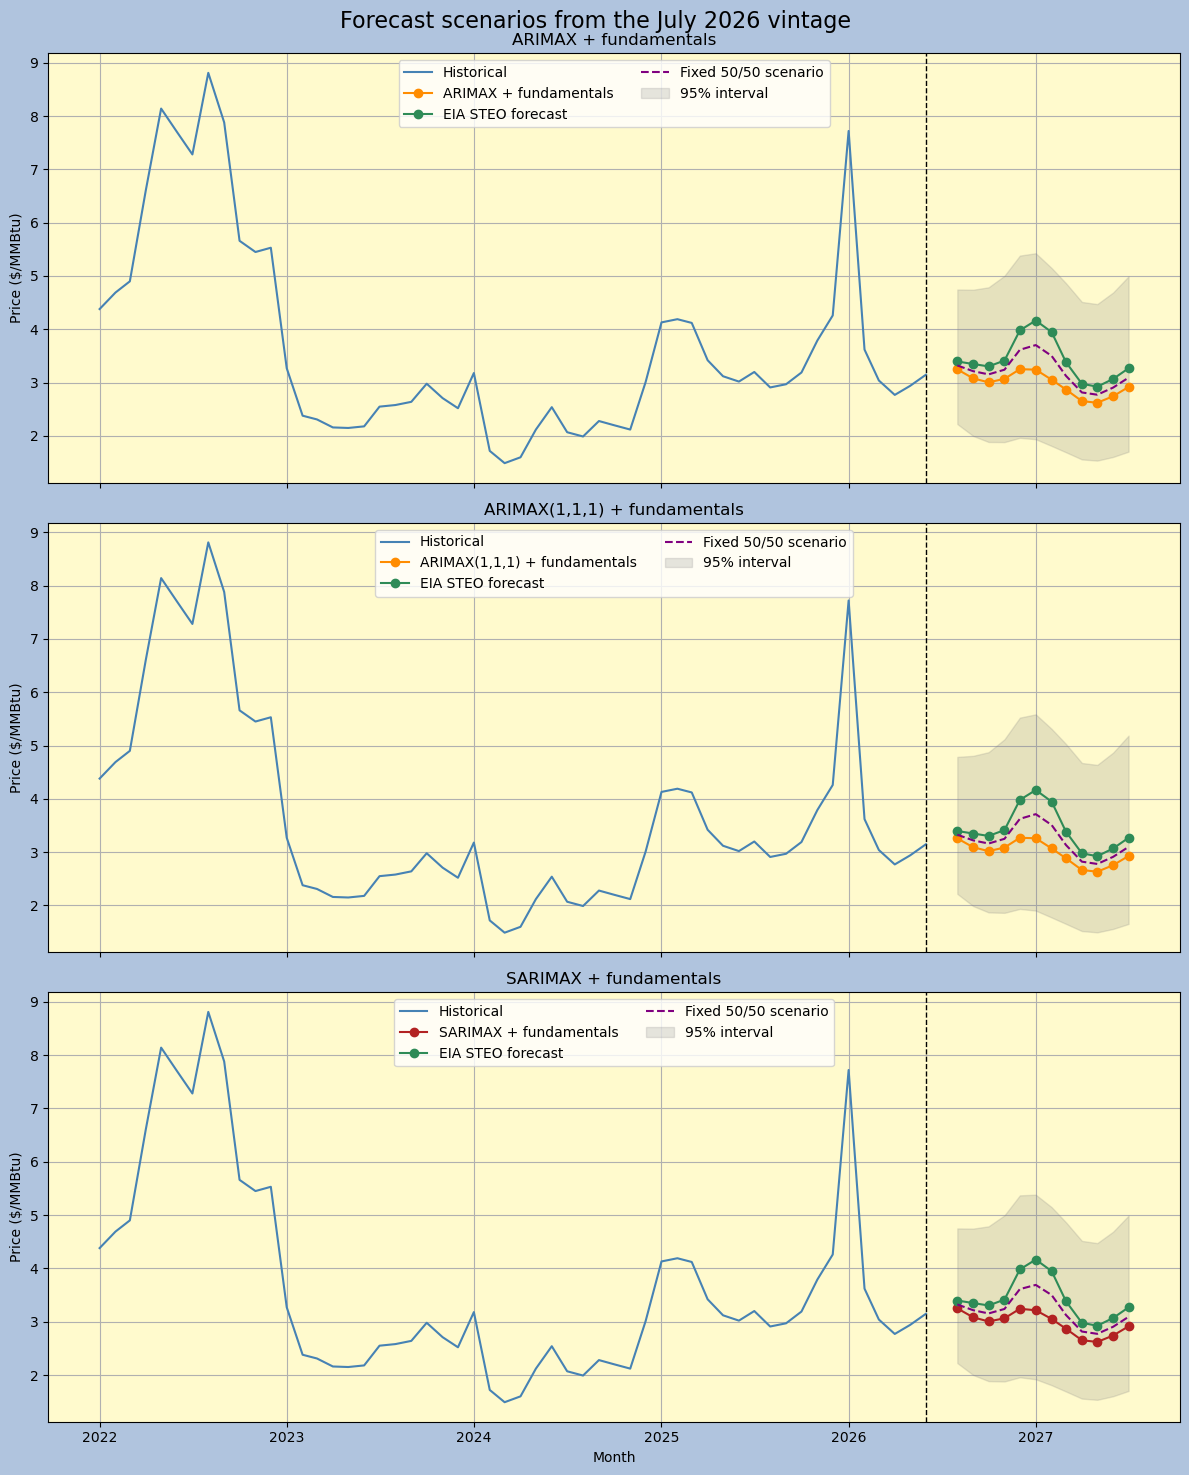

In [63]:
# Use only prices that were available before the July 2026 release
recent_prices = gas_prices.loc["2022-01-01":"2026-06-01"]

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 15),
    sharex=True,
    facecolor=FIGURE_COLOUR,
)

# Plot the selected ARIMAX forecast
ax = axes[0]

ax.set_facecolor(AXIS_COLOUR)
ax.set_axisbelow(True)

ax.plot(
    recent_prices.index.to_numpy(),
    recent_prices["Price"].to_numpy(),
    color=HISTORICAL_COLOUR,
    label="Historical",
)

ax.plot(
    selected_current.index.to_numpy(),
    selected_current["Forecast"].to_numpy(),
    marker="o",
    color=FORECAST_COLOUR,
    label=selected_model,
)

ax.plot(
    eia_current.index.to_numpy(),
    eia_current.to_numpy(),
    marker="o",
    color="seagreen",
    label="EIA STEO forecast",
)

ax.plot(
    selected_blend.index.to_numpy(),
    selected_blend.to_numpy(),
    linestyle="--",
    color="purple",
    label="Fixed 50/50 scenario",
)

ax.fill_between(
    selected_current.index.to_numpy(),
    selected_current["Lower"].to_numpy(),
    selected_current["Upper"].to_numpy(),
    color="grey",
    alpha=0.2,
    label="95% interval",
)

ax.axvline(
    pd.Timestamp("2026-06-01"),
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title("ARIMAX + fundamentals")
ax.set_ylabel("Price ($/MMBtu)")
ax.legend(ncol=2)


# Plot the first-differenced ARIMAX forecast
ax = axes[1]

ax.set_facecolor(AXIS_COLOUR)
ax.set_axisbelow(True)

ax.plot(
    recent_prices.index.to_numpy(),
    recent_prices["Price"].to_numpy(),
    color=HISTORICAL_COLOUR,
    label="Historical",
)

ax.plot(
    d1_current.index.to_numpy(),
    d1_current["Forecast"].to_numpy(),
    marker="o",
    color="darkorange",
    label="ARIMAX(1,1,1) + fundamentals",
)

ax.plot(
    eia_current.index.to_numpy(),
    eia_current.to_numpy(),
    marker="o",
    color="seagreen",
    label="EIA STEO forecast",
)

ax.plot(
    d1_blend.index.to_numpy(),
    d1_blend.to_numpy(),
    linestyle="--",
    color="purple",
    label="Fixed 50/50 scenario",
)

ax.fill_between(
    d1_current.index.to_numpy(),
    d1_current["Lower"].to_numpy(),
    d1_current["Upper"].to_numpy(),
    color="grey",
    alpha=0.2,
    label="95% interval",
)

ax.axvline(
    pd.Timestamp("2026-06-01"),
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title("ARIMAX(1,1,1) + fundamentals")
ax.set_ylabel("Price ($/MMBtu)")
ax.legend(ncol=2)


# Plot the seasonal SARIMAX forecast
ax = axes[2]

ax.set_facecolor(AXIS_COLOUR)
ax.set_axisbelow(True)

ax.plot(
    recent_prices.index.to_numpy(),
    recent_prices["Price"].to_numpy(),
    color=HISTORICAL_COLOUR,
    label="Historical",
)

ax.plot(
    sarimax_current.index.to_numpy(),
    sarimax_current["Forecast"].to_numpy(),
    marker="o",
    color="firebrick",
    label="SARIMAX + fundamentals",
)

ax.plot(
    eia_current.index.to_numpy(),
    eia_current.to_numpy(),
    marker="o",
    color="seagreen",
    label="EIA STEO forecast",
)

ax.plot(
    sarimax_blend.index.to_numpy(),
    sarimax_blend.to_numpy(),
    linestyle="--",
    color="purple",
    label="Fixed 50/50 scenario",
)

ax.fill_between(
    sarimax_current.index.to_numpy(),
    sarimax_current["Lower"].to_numpy(),
    sarimax_current["Upper"].to_numpy(),
    color="grey",
    alpha=0.2,
    label="95% interval",
)

ax.axvline(
    pd.Timestamp("2026-06-01"),
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title("SARIMAX + fundamentals")
ax.set_xlabel("Month")
ax.set_ylabel("Price ($/MMBtu)")
ax.legend(ncol=2)

fig.suptitle(
    "Forecast scenarios from the July 2026 vintage",
    fontsize=16,
)

plt.tight_layout()
plt.show()

The July 2026 ARIMAX, ARIMAX(1,1,1) and SARIMAX forecasts produce similar central price paths. In particular, the similarity between ARIMAX + fundamentals and SARIMAX + fundamentals suggests that the annual seasonal term has little effect on the current forecast. All three forecasts are conditional on the storage and degree day forecasts from the July 2026 EIA vintage and should be treated as forecast scenarios rather than known future prices.

The EIA price forecast has a larger winter peak. It is retained as an external benchmark and is never used as an input to the ARIMAX or SARIMAX price models.

Each fixed 50/50 path is an illustrative midpoint between the corresponding statistical model and the EIA forecast. These combinations were not selected through the development backtest and are not presented as more accurate forecasts.

## 10. Storage decision model

The storage model decides **when to buy gas, store it, and sell it later** based on a fixed forecast price path.

Inventory changes each month according to

$$
S_{t+1}=S_t+\eta_I I_t-\frac{W_t}{\eta_W}.
$$

where:

1. $S_t$ = gas currently in storage  
2. $I_t$ = gas bought and injected  
3. $W_t$ = gas withdrawn and sold  
4. $\eta_I,\eta_W$ = injection and withdrawal efficiencies  

In simple terms:
$$ \text{new inventory} = \text{old inventory} + \text{gas added} - \text{gas removed} $$

The storage facility also has limits:

$$ 0\leq S_{t+1}\leq C, \qquad 0\leq I_t\leq I^{\max}, \qquad 0\leq W_t\leq W^{\max} $$

where:

1. $C$ = maximum storage capacity  
2. $I^{\max}$ = maximum monthly injection  
3. $W^{\max}$ = maximum monthly withdrawal  

The facility starts and finishes with zero inventory, so all gas bought during the contract must eventually be sold.

The monthly discounted cash flow is

$$ D_t\left[ W_t(P_t-c_W) - I_t(P_t+c_I) - c_HS_{t+1} - F \right] $$

where:

1. $P_t$ = gas price  
2. $c_I$ = injection cost  
3. $c_W$ = withdrawal cost  
4. $c_H$ = storage/holding cost  
5. $F$ = fixed monthly fee  
6. $D_t$ = discount factor  

In simple terms:

$$ \text{cash flow} = \text{money from selling gas} - \text{cost of buying and storing gas} $$

`storage_valuation.py` uses linear programming to find the combination of monthly injections and withdrawals that gives the **highest discounted value while obeying all storage limits**

### Storage contract assumptions

| Assumption | Illustrative value |
|---|---:|
| Working capacity | 1,000,000 MMBtu |
| Maximum monthly injection | 200,000 MMBtu |
| Maximum monthly withdrawal | 200,000 MMBtu |
| Initial inventory | 0 MMBtu |
| Final inventory | 0 MMBtu |
| Injection efficiency | 98% |
| Withdrawal efficiency | 98% |
| Injection cost | $0.03/MMBtu |
| Withdrawal cost | $0.03/MMBtu |
| Monthly holding cost | $0.01/MMBtu of inventory |
| Monthly contract fee | $0 |
| Annual discount rate | 5% |

In [64]:
# Contract assumptions
contract_assumptions = {
    "capacity": 1_000_000,
    "max_injection": 200_000,
    "max_withdrawal": 200_000,
    "initial_inventory": 0,
    "final_inventory": 0,
    "injection_efficiency": 0.98,
    "withdrawal_efficiency": 0.98,
    "injection_cost": 0.03,
    "withdrawal_cost": 0.03,
    "holding_cost": 0.01,
    "monthly_contract_fee": 0,
    "annual_discount_rate": 0.05,
}


These parameters are illustrative rather than quoted market terms. Their purpose is to make the units, losses and constraints explicit so the assumptions can be easily reviewed and changed.

In [65]:
selected_scenario_name = f"Selected model ({selected_model})"
d1_scenario_name = "ARIMAX(1,1,1) + fundamentals"
sarimax_scenario_name = "SARIMAX + fundamentals"
blended_scenario_name = "50/50 selected-model and EIA scenario"
# Store each price path that will be used for storage valuation
valuation_scenarios = {
    "Flat last-price scenario": last_price_current,
    selected_scenario_name: selected_current["Forecast"],
    d1_scenario_name: d1_current["Forecast"],
    sarimax_scenario_name: sarimax_current["Forecast"],
    blended_scenario_name: selected_blend,
    "EIA STEO scenario": eia_current,
}

scenario_rows = []
scenario_schedules = {}

# Optimise the storage strategy separately for each price scenario
for scenario_name, price_curve in valuation_scenarios.items():
    schedule, value = optimise_storage_schedule(price_curve, **contract_assumptions)

    # Store the optimal monthly storage schedule
    scenario_schedules[scenario_name] = schedule
    # Store the main valuation results for this scenario
    scenario_rows.append({
        "Price scenario": scenario_name,
        "Forecast contract NPV": value["Forecast contract NPV"],
        "Total injected": value["Total injected"],
        "Total withdrawn": value["Total withdrawn"],
        "Peak inventory": value["Peak inventory"],
    })

# Combine the scenario results into one table and sort by contract value
scenario_valuation = pd.DataFrame(scenario_rows).sort_values("Forecast contract NPV")
scenario_valuation

,Price scenario,Forecast contract NPV,Total injected,Total withdrawn,Peak inventory
0,Flat last-price scenario,0.000000,0.000000,0.0,0.000000
3,SARIMAX + fundamentals,16021.075933,408246.563932,392080.0,204081.632653
1,Selected model (ARIMAX + fundamentals),18325.608669,408246.563932,392080.0,204081.632653
2,"ARIMAX(1,1,1) + fundamentals",18547.422368,408246.563932,392080.0,204081.632653
4,50/50 selected-model and EIA scenario,103945.573577,624739.691795,600000.0,408163.265306
5,EIA STEO scenario,254571.952683,832986.255727,800000.0,612244.897959


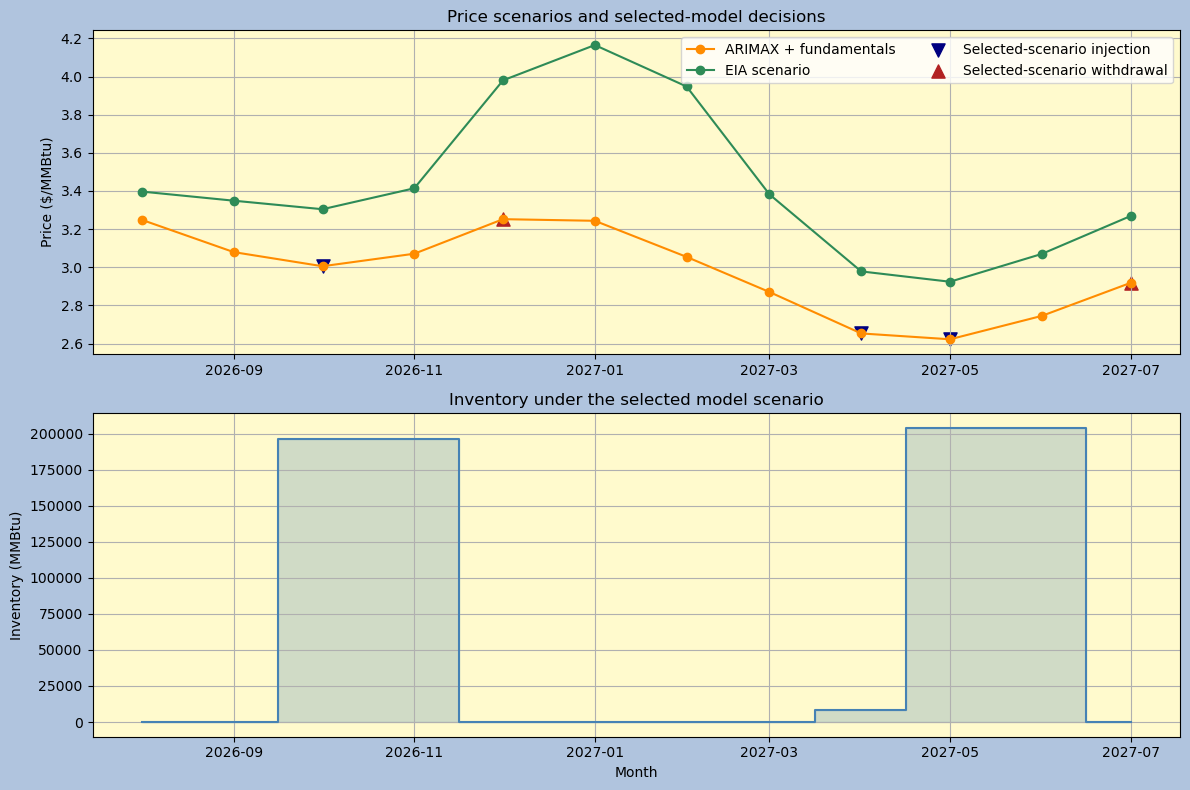

In [66]:
# Get the optimal storage schedule for the selected ARIMAX scenario
selected_schedule = scenario_schedules[selected_scenario_name]

# Create separate plots for the price decisions and resulting inventory
fig, axes = plt.subplots(2, 1, figsize=(12, 8), facecolor=FIGURE_COLOUR)
for ax in axes:
    ax.set_facecolor(AXIS_COLOUR)

axes[0].plot(
    selected_current.index.to_numpy(),
    selected_current["Forecast"].to_numpy(),
    marker="o",
    color=FORECAST_COLOUR,
    label=selected_model,
)
axes[0].plot(
    eia_current.index.to_numpy(),
    eia_current.to_numpy(),
    marker="o",
    color="seagreen",
    label="EIA scenario",
)

# Identify the months where the optimiser injects or withdraws gas
injection_months = selected_schedule["Injection"] > 0
withdrawal_months = selected_schedule["Withdrawal"] > 0

# Mark injection months on the ARIMAX price path
axes[0].scatter(
    selected_schedule.index[injection_months].to_numpy(),
    selected_schedule.loc[injection_months, "Forecast price"].to_numpy(),
    marker="v",
    s=90,
    color="navy",
    label="Selected-scenario injection",
)
# Mark withdrawal months on the ARIMAX price path
axes[0].scatter(
    selected_schedule.index[withdrawal_months].to_numpy(),
    selected_schedule.loc[withdrawal_months, "Forecast price"].to_numpy(),
    marker="^",
    s=90,
    color="firebrick",
    label="Selected-scenario withdrawal",
)
axes[0].set_title("Price scenarios and selected-model decisions")
axes[0].set_ylabel("Price ($/MMBtu)")
axes[0].legend(ncol=2)

# Plot how inventory changes under the optimal ARIMAX schedule
axes[1].step(
    selected_schedule.index.to_numpy(),
    selected_schedule["Closing inventory"].to_numpy(),
    where="mid",
    color=HISTORICAL_COLOUR,
)
axes[1].fill_between(
    selected_schedule.index.to_numpy(),
    selected_schedule["Closing inventory"].to_numpy(),
    step="mid",
    color=HISTORICAL_COLOUR,
    alpha=0.25,
)
axes[1].set_title("Inventory under the selected model scenario")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Inventory (MMBtu)")

plt.tight_layout()
plt.show()

### Valuation result

Under the assumptions, the July 2026 forecast NPV is about $18,500 using ARIMAX(1,1,1) with fundamentals, $18,300 using the selected ARIMAX + fundamentals model and $16,000 using SARIMAX + fundamentals. All three statistical models produce essentially the same storage schedule, so the differences between their current forecast paths have little effect on the storage decision.

The fixed 50/50 selected-model/EIA path gives about $103,900, while the EIA path gives about $254,600. A flat price path produces no storage activity and a value of zero. The 50/50 case is an illustrative midpoint and was not selected through the development backtest.

The large difference between the statistical model values and the EIA-based values shows how sensitive the storage decision is to the assumed price path. Changes in the timing and size of forecast price spreads can substantially change the estimated value of storage.

> These results do not overturn the original model choice. The $d=1$ ARIMAX and seasonal SARIMAX have now served as robustness checks, so the remaining economic backtest focuses on the selected ARIMAX and the external EIA benchmark.

## 11. Storage decision backtest

A positive forecast NPV does not show that the planned schedule would retain value once prices are realised. We therefore repeat the storage exercise at each historical forecast year:

1. optimise the schedule using only the forecast available at the time
2. freeze every injection and withdrawal decision
3. replace forecast prices with the later realised monthly prices
4. recalculate the discounted value without re-optimising

Freezing the schedule prevents hindsight. This tests whether the forecast captures the price spreads and timing needed for a useful storage decision, which is a different question from minimising average price error.

In [67]:
# Create a container for the economic backtest results
economic_rows = []

for forecast_year in range(2017, 2026):
    forecast_year_results = backtest_results[backtest_results["Forecast Year"] == forecast_year]

    # Get the realised and forecast curves for this forecast year
    actual_curve = (
        forecast_year_results[forecast_year_results["Model"] == selected_model]
        .set_index("Date")["Actual"]
    )
    selected_curve = (
        forecast_year_results[forecast_year_results["Model"] == selected_model]
        .set_index("Date")["Forecast"]
    )
    eia_curve = (
        forecast_year_results[forecast_year_results["Model"] == "EIA STEO forecast"]
        .set_index("Date")["Forecast"]
    )

    # Test the selected-model and EIA schedules separately
    for scenario_name, forecast_curve in {
        selected_scenario_name: selected_curve,
        "EIA STEO scenario": eia_curve,
    }.items():
        schedule, forecast_value = optimise_storage_schedule(
            forecast_curve,
            **contract_assumptions,
        )
        _, realised_value = evaluate_frozen_schedule(schedule, actual_curve)

        economic_rows.append({
            "Forecast Year": forecast_year,
            "Scenario": scenario_name,
            "Forecast NPV": forecast_value["Forecast contract NPV"],
            "Realised frozen-schedule NPV": realised_value,
        })

economic_backtest = pd.DataFrame(economic_rows)


def count_near_zero(values):
    return np.isclose(values, 0, atol=1e-6).sum()


# Summarise the separate annual exercises without adding NPVs from different forecast dates
economic_summary = (
    economic_backtest.groupby("Scenario")
    .agg(
        Mean_forecast_NPV=("Forecast NPV", "mean"),
        Median_forecast_NPV=("Forecast NPV", "median"),
        Mean_realised_NPV=("Realised frozen-schedule NPV", "mean"),
        Median_realised_NPV=("Realised frozen-schedule NPV", "median"),
        Positive_periods=(
            "Realised frozen-schedule NPV",
            lambda values: (values > 1e-6).sum(),
        ),
        Zero_periods=("Realised frozen-schedule NPV", count_near_zero),
        Negative_periods=(
            "Realised frozen-schedule NPV",
            lambda values: (values < -1e-6).sum(),
        ),
    )
)

display(economic_backtest.pivot(
    index="Forecast Year",
    columns="Scenario",
    values="Realised frozen-schedule NPV",
))
display(economic_summary)

Scenario,EIA STEO scenario,Selected model (ARIMAX + fundamentals)
Forecast Year,,
2017,-3.462610e+04,-39095.358712
2018,0.000000e+00,-180607.474112
2019,-3.196258e+05,-319625.759575
2020,6.886531e+05,905091.089660
2021,0.000000e+00,-551609.732437
2022,0.000000e+00,0.000000
2023,-3.445488e+05,-25306.494996
2024,6.038861e+05,-92140.264216
2025,1.069737e+06,-24433.700663


,Mean_forecast_NPV,Median_forecast_NPV,Mean_realised_NPV,Median_realised_NPV,Positive_periods,Zero_periods,Negative_periods
Scenario,,,,,,,
EIA STEO scenario,226790.691513,176067.126196,184830.552610,0.000000,3,3,3
Selected model (ARIMAX + fundamentals),67576.678666,44620.659676,-36414.188339,-39095.358712,1,1,7


Across the nine annual exercises, the selected model schedule has a positive realised frozen-schedule value once, zero value once and a negative value seven times. Its mean realised value is about -$36,400 and its median is about -$39,100.

The EIA schedules have three positive, three zero and three negative periods. Their mean realised value is about $184,800, but the median is zero. The no action years are meaningful because the published curve did not justify paying the storage costs.

Each annual contract is decided and discounted at a different July forecast date. We therefore compare the distribution and sign of the outcomes rather than summing them into the NPV of one continuous strategy.

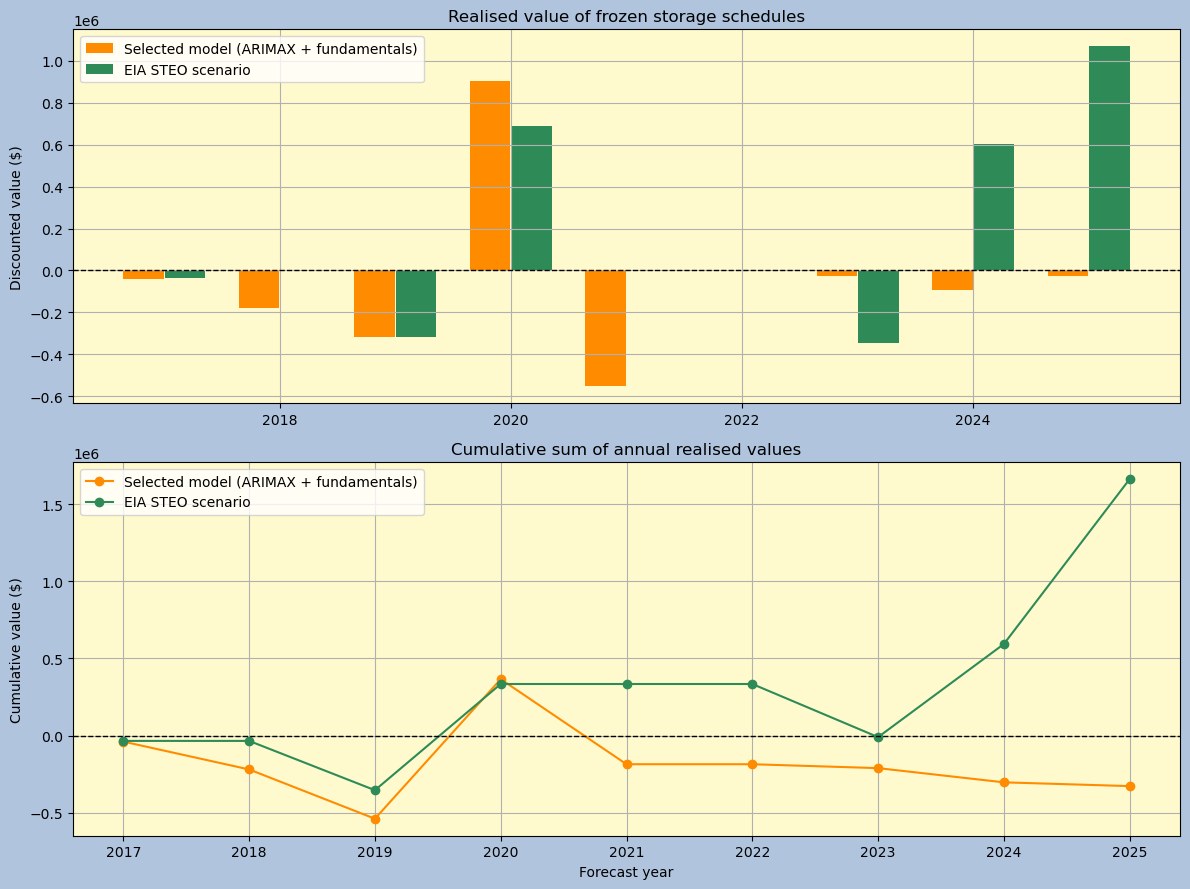

In [72]:
# Plot realised schedule values and cumulative sums
fig, axes = plt.subplots(2, 1, figsize=(12, 9), facecolor=FIGURE_COLOUR)

for ax in axes:
    ax.set_facecolor(AXIS_COLOUR)

# Plot ARIMAX and EIA results for each forecast year
for scenario_name, colour in {
    selected_scenario_name: FORECAST_COLOUR,
    "EIA STEO scenario": "seagreen",
}.items():

    # Get the economic backtest results for this scenario
    scenario_results = (
        economic_backtest[economic_backtest["Scenario"] == scenario_name]
        .sort_values("Forecast Year")
    )

    # Shift the bars slightly so both scenarios can be compared side by side
    bar_offset = -0.18 if scenario_name == selected_scenario_name else 0.18

    # Plot the realised value of the frozen schedule for each forecast year
    axes[0].bar(
        scenario_results["Forecast Year"].to_numpy() + bar_offset,
        scenario_results["Realised frozen-schedule NPV"].to_numpy(),
        width=0.35,
        color=colour,
        label=scenario_name,
    )

    # Calculate and plot the cumulative sum of annual realised values
    cumulative_value = scenario_results["Realised frozen-schedule NPV"].cumsum()

    axes[1].plot(
        scenario_results["Forecast Year"].to_numpy(),
        cumulative_value.to_numpy(),
        marker="o",
        color=colour,
        label=scenario_name,
    )

# Mark the break-even point between profit and loss
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)

axes[0].set_title("Realised value of frozen storage schedules")
axes[0].set_ylabel("Discounted value ($)")
axes[0].legend()

axes[1].set_title("Cumulative sum of annual realised values")
axes[1].set_xlabel("Forecast year")
axes[1].set_ylabel("Cumulative value ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Backtest result

This answers the second research question. Lower average price error does not guarantee that a forecast captures the particular price spreads and timing needed by the storage optimiser. The selected ARIMAX has the lowest pooled development MAE, but its frozen schedule has a positive realised value in only one of nine annual exercises.

The EIA schedules are also inconsistent and their median realised value is zero, although several later forecast years produce much larger positive realised values. These are illustrative monthly decision backtests rather than verified trading profits or the value of one continuous strategy.

## 12. Sensitivity analysis

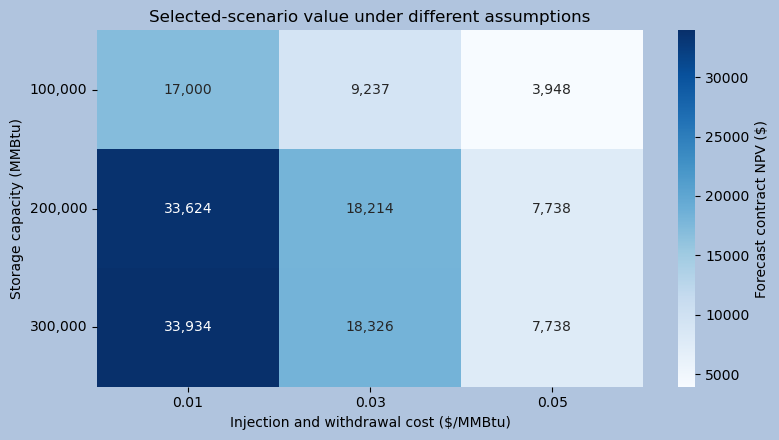

In [73]:
# Sensitivity analysis
sensitivity_rows = []

# Test three different storage capacities
for capacity in [100_000, 200_000, 300_000]:
    # Test three different injection and withdrawal costs
    for operating_cost in [0.01, 0.03, 0.05]:
        # Copy the original contract assumptions
        sensitivity_assumptions = contract_assumptions.copy()
         # Change only the capacity and operating costs
        sensitivity_assumptions.update({
            "capacity": capacity,
            "injection_cost": operating_cost,
            "withdrawal_cost": operating_cost,
        })
        # Revalue the storage contract using the ARIMAX forecast
        _, sensitivity_value = optimise_storage_schedule(
            selected_current["Forecast"],
            **sensitivity_assumptions,
        )
        # Store the assumptions and resulting contract value
        sensitivity_rows.append({
            "Capacity": capacity,
            "Injection and withdrawal cost": operating_cost,
            "Forecast contract NPV": sensitivity_value["Forecast contract NPV"],
        })

# Arrange the results into a table
sensitivity_table = pd.DataFrame(sensitivity_rows).pivot(
    index="Capacity",
    columns="Injection and withdrawal cost",
    values="Forecast contract NPV",
)

# Plot the sensitivity results as a heatmap
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=FIGURE_COLOUR)
ax.set_facecolor(AXIS_COLOUR)
sns.heatmap(
    sensitivity_table,
    annot=True,
    fmt=",.0f",
    cmap="Blues",
    cbar_kws={"label": "Forecast contract NPV ($)"},
    ax=ax,
)
ax.set_title("Selected-scenario value under different assumptions")
ax.set_xlabel("Injection and withdrawal cost ($/MMBtu)")
ax.set_ylabel("Storage capacity (MMBtu)")
ax.set_yticklabels([f"{int(value):,}" for value in sensitivity_table.index], rotation=0)
plt.tight_layout()
plt.grid(False)
plt.show()

Under the July 2026 selected-model forecast, storage value is sensitive to both capacity and operating costs. At the base operating cost, increasing capacity from $100,000$ to $200,000$ MMBtu raises forecast NPV from about $9,200 to $18,200. Increasing capacity further to 300,000 MMBtu adds very little under this forecast path.

Operating costs also have a large effect. At $300,000$ MMBtu capacity, increasing the injection and withdrawal charge from $0.01$ to $0.05$/MMBtu reduces forecast NPV from about $33,900 to $7,700.

These results show that the estimated storage value depends materially on the contract assumptions as well as the assumed forecast price path.

## Research findings

The first research question asks whether storage and weather information improves the 12 month Henry Hub forecast. Across the seven development years, ARIMAX using storage, HDD and CDD performs best, with a pooled MAE of $0.890$ \$/MMBtu and RMSE of $1.322$ \$/MMBtu. This is better than the price only ARIMA, SARIMA and EIA forecasts. Adding a seasonal AR term does not improve the fundamentals model.

We also test $d=1$ models because the ADF test suggests the price series may be non-stationary. The best $d=1$ model has a pooled MAE of $1.086$, so it does not beat the selected ARIMAX overall. However, the $d=1$ models perform better in some individual years, showing that the choice between modelling price levels and price changes is still a source of model risk.

The later results are also mixed. EIA performs best in 2024, while a $d=1$ fundamentals model is slightly better in 2025. The selected model's 95% intervals contain only 77.4% of the development observations, suggesting that the model underestimates forecast uncertainty.

The second research question asks whether a more accurate price forecast also produces better storage decisions. Under the July 2026 assumptions, the selected ARIMAX forecast gives a storage NPV of about $18,300, compared with about $254,600 using the EIA forecast. In the historical frozen schedule test, the selected model schedule has a positive realised value in only one of nine years, with a mean of about -$36,400 and median of about -$39,100.

The main conclusion is that adding storage and weather information improves average forecast accuracy in this study, but better price forecasts do not automatically lead to better storage decisions. The storage results should therefore be treated as model dependent decision support rather than a market valuation.

## Limitations

- The target is a monthly spot-price average rather than a traded forward curve.
- The level model is selected for forecast performance despite the unit-root evidence; its advantage is partly linked to the 2022 forecast year.
- Future storage, HDD and CDD are EIA forecasts, so uncertainty in those paths is omitted from the conditional model intervals.
- The EIA price benchmark may contain broader analyst judgement and related assumptions, so it is external rather than fully independent econometric evidence.
- Seven development forecast years cover a limited set of market regimes.
- The first development forecast year has only 54 monthly training observations, limiting confidence in longer seasonal relationships.
- Forecast storage and weather paths cannot anticipate every supply, weather or geopolitical shock.
- The central log price forecast is a conditional median rather than a bias-corrected expected price.
- The storage contract assumptions are illustrative rather than quoted facility terms.
- The monthly storage model omits daily deliverability, bid-ask spreads, market impact, liquidity, credit and other operational detail.
- This redesign was informed by the full historical record, so 2024 and 2025 are later evaluations rather than untouched prospective tests.